# Parcial · Corte 1 — Shiro Twin

**Aprendizaje de Máquina · Universidad Sergio Arboleda · Semestre 26-2**
Grupo Shiro — Jose Leonardo Diazgranados, Sofía Londoño, Andrés Felipe Céspedes Rondón, Alex Duran
Docente: Hernán Darío Cruz Bueno · Sector: Energía y Medio Ambiente / IoT

---

## Qué componente de Shiro construye este parcial

Shiro Twin es un gemelo digital de un hogar: una simulación sobre la que un agente de refuerzo
aprenderá a operar la casa gastando menos sin quitar comodidad. Ese agente no puede entrenarse
hasta que existan dos piezas, y este parcial las decide:

| Pieza del gemelo | Qué falta decidir | Punto del parcial que lo resuelve |
|---|---|---|
| **Función de transición** — qué consumo devuelve el simulador ante un estado | Cuál de los cuatro modelos entrenados la implementa | **1.** Comparativo histórico |
| **Incertidumbre del simulador** — cuánto miente y dónde | Si el error es uniforme o concentrado, y si es reparable | **2.** Análisis de errores críticos |
| **Garantías de la capa Guardian** — qué promete el sistema y a quién | Qué falla, a quién le cuesta y qué se puede explicar | **3.** Comparación ética o de impacto |
| **Lazo `iot-bridge`** — cómo llega una predicción a una persona | Qué se automatiza, con qué umbral y con qué salida manual | **4.** Simulación de decisión automatizada |

La pregunta que ordena el cuaderno no es *qué tan bueno es cada algoritmo*, sino
**qué puede y qué no puede sostener el gemelo digital con lo que hoy tenemos medido**.

## Metodología heredada (Talleres 1, 2 y 3 — sin cambios)

Se reutilizan sin modificar, para que todo sea comparable punto a punto:

- **29 variables predictoras**: 4 temporales derivadas de la marca de tiempo, `lights`,
  18 sensores interiores (`T1`–`T9`, `RH_1`–`RH_9`) y 6 de clima exterior.
  Se excluyen `rv1` y `rv2` (ruido inyectado por los autores del dataset).
- **Dos particiones, siempre las dos**: aleatoria 80/20 (`random_state=42`) como principal
  y temporal (último mes reservado) como control de robustez.
- **Umbral de anomalía**: percentil 90 del consumo *de entrenamiento* ≈ 200 Wh.
- **Escalado**: `StandardScaler` ajustado solo sobre entrenamiento (KNN y SVM).
- **Semilla** `random_state=42` en todo.

---
## 1. Carga y preparación (idéntica a los Talleres 2 y 3)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
import warnings
warnings.filterwarnings("ignore")

RS = 42
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "savefig.bbox": "tight"})

# Paleta consistente en todo el cuaderno
COL = {"lin": "#9aa0a6", "arbol": "#e8710a", "knn": "#1a73e8",
       "rf": "#188038", "svm": "#a142f4", "alerta": "#d93025"}

In [2]:
CSV = "../../data set/energydata_complete.csv"   # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])

df["hora"]          = df["date"].dt.hour
df["dia_semana"]    = df["date"].dt.dayofweek
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)
df["mes"]           = df["date"].dt.month

def franja(h):
    if h < 6:  return "Madrugada (00-06)"
    if h < 12: return "Mañana (06-12)"
    if h < 18: return "Tarde (12-18)"
    return "Noche (18-24)"
df["franja"] = df["hora"].apply(franja)

TEMPORALES = ["hora", "dia_semana", "es_fin_semana", "mes"]
INTERIOR   = [c for c in df.columns
              if c.startswith(("T", "RH_")) and c not in ("T_out", "RH_out", "Tdewpoint")]
CLIMA      = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
FEATURES   = TEMPORALES + ["lights"] + INTERIOR + CLIMA
TARGET     = "Appliances"

X, y = df[FEATURES], df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=RS)

dfo   = df.sort_values("date").reset_index(drop=True)
corte = int(len(dfo) * .8)
Xt_tr, yt_tr = dfo.iloc[:corte][FEATURES], dfo.iloc[:corte][TARGET]
Xt_te, yt_te = dfo.iloc[corte:][FEATURES], dfo.iloc[corte:][TARGET]

UMBRAL = np.percentile(y_tr, 90)
c_tr,  c_te  = (y_tr  > UMBRAL).astype(int), (y_te  > UMBRAL).astype(int)
ct_tr, ct_te = (yt_tr > UMBRAL).astype(int), (yt_te > UMBRAL).astype(int)

scaler = StandardScaler().fit(X_tr)
Xs_tr, Xs_te = scaler.transform(X_tr), scaler.transform(X_te)
sc_t = StandardScaler().fit(Xt_tr)
Xst_tr, Xst_te = sc_t.transform(Xt_tr), sc_t.transform(Xt_te)

print(f"{len(FEATURES)} variables predictoras · {len(df):,} filas · {df.isna().sum().sum()} faltantes")
print(f"Aleatoria: {len(X_tr):,} entrena / {len(X_te):,} prueba")
print(f"Temporal:  entrena hasta {dfo.date.iloc[corte-1]} · prueba desde {dfo.date.iloc[corte]}")
print(f"Umbral de anomalía: {UMBRAL:.0f} Wh · anomalías en prueba: {c_te.sum()} ({c_te.mean()*100:.1f} %)")

29 variables predictoras · 19,735 filas · 0 faltantes
Aleatoria: 15,788 entrena / 3,947 prueba
Temporal:  entrena hasta 2016-04-30 08:10:00 · prueba desde 2016-04-30 08:20:00
Umbral de anomalía: 200 Wh · anomalías en prueba: 379 (9.6 %)


---
# Punto 1 — Comparativo histórico de modelos

**Decisión de Shiro que depende de esto:** el gemelo digital necesita *una* función de transición.
Ante un estado (hora, tipo de día, temperaturas, humedades, clima) debe devolver el consumo
esperado. Cuatro modelos compiten por ese puesto y este punto los ordena.

El comparativo no es una tabla de resultados: es la reconstrucción de **por qué** el proyecto pasó
de un modelo al siguiente, qué cambió en el preprocesamiento en cada paso y qué se aprendió.

## 1.1 Línea de tiempo del proyecto

In [3]:
timeline = pd.DataFrame([
    dict(Hito="T1 · 16-ago", Modelo="— (selección de dataset)",
         Preprocesamiento="Ninguno. Rúbrica de 5 criterios sobre 3 candidatos.",
         Motivo="Appliances (24/25) es el único con temperatura y humedad interior por habitación; "
                "sin eso no se puede calcular la penalización de confort de la recompensa del MDP."),
    dict(Hito="T2 · 16-ago", Modelo="Árbol de Decisión",
         Preprocesamiento="+4 variables temporales derivadas (hora, día, fin de semana, mes). "
                          "Se excluyen rv1/rv2. Se fijan las DOS particiones.",
         Motivo="Primer modelo interpretable: se necesita ver qué reglas aprende, no solo cuánto acierta."),
    dict(Hito="T2 · 16-ago", Modelo="KNN (K=3 clf / K=5 reg)",
         Preprocesamiento="+StandardScaler ajustado SOLO sobre entrenamiento.",
         Motivo="El árbol no usa distancias; KNN sí, y sin escalar Press_mm_hg (~750) aplasta a lights (0-70)."),
    dict(Hito="T3 · 3-sep", Modelo="Regresión Lineal",
         Preprocesamiento="Sin cambios.",
         Motivo="Faltaba una línea base honesta: ¿cuánto de esto lo explica una relación lineal?"),
    dict(Hito="T3 · 3-sep", Modelo="Random Forest",
         Preprocesamiento="Sin cambios (mismas 29 variables, mismas particiones).",
         Motivo="Continuación natural del árbol. 16 combinaciones en barrido secuencial "
                "n_estimators → max_depth → min_samples_leaf."),
    dict(Hito="T3 · 3-sep", Modelo="SVM (rbf) y SVM balanceado",
         Preprocesamiento="+submuestra estratificada de 4.000 filas para ENTRENAR "
                          "(evaluación sobre el test completo). +class_weight='balanced'.",
         Motivo="SVM no converge sobre 15.788 filas. El balanceo se añade porque 6 de 9 "
                "combinaciones colapsaban a clasificador trivial (F1 = 0,000)."),
    dict(Hito="Parcial · 9-sep", Modelo="RF + variables de retardo",
         Preprocesamiento="+lag1, lag2, lag3, lag6, media/max/std de la última hora. "
                          "Evaluado SOLO en partición temporal.",
         Motivo="Propuesta de mejora del punto 2, medida y no solo afirmada (sección 2.4)."),
])
pd.set_option("display.max_colwidth", 200)
timeline

,Hito,Modelo,Preprocesamiento,Motivo
0,T1 · 16-ago,— (selección de dataset),Ninguno. Rúbrica de 5 criterios sobre 3 candidatos.,Appliances (24/25) es el único con temperatura y humedad interior por habitación; sin eso no se puede calcular la penalización de confort de la recompensa del MDP.
1,T2 · 16-ago,Árbol de Decisión,"+4 variables temporales derivadas (hora, día, fin de semana, mes). Se excluyen rv1/rv2. Se fijan las DOS particiones.","Primer modelo interpretable: se necesita ver qué reglas aprende, no solo cuánto acierta."
2,T2 · 16-ago,KNN (K=3 clf / K=5 reg),+StandardScaler ajustado SOLO sobre entrenamiento.,"El árbol no usa distancias; KNN sí, y sin escalar Press_mm_hg (~750) aplasta a lights (0-70)."
3,T3 · 3-sep,Regresión Lineal,Sin cambios.,Faltaba una línea base honesta: ¿cuánto de esto lo explica una relación lineal?
4,T3 · 3-sep,Random Forest,"Sin cambios (mismas 29 variables, mismas particiones).",Continuación natural del árbol. 16 combinaciones en barrido secuencial n_estimators → max_depth → min_samples_leaf.
5,T3 · 3-sep,SVM (rbf) y SVM balanceado,+submuestra estratificada de 4.000 filas para ENTRENAR (evaluación sobre el test completo). +class_weight='balanced'.,"SVM no converge sobre 15.788 filas. El balanceo se añade porque 6 de 9 combinaciones colapsaban a clasificador trivial (F1 = 0,000)."
6,Parcial · 9-sep,RF + variables de retardo,"+lag1, lag2, lag3, lag6, media/max/std de la última hora. Evaluado SOLO en partición temporal.","Propuesta de mejora del punto 2, medida y no solo afirmada (sección 2.4)."


**Los tres cambios de preprocesamiento del proyecto, y por qué cada uno.**

1. **Variables temporales derivadas** (Taller 2). La marca de tiempo cruda es inútil para un modelo;
   descompuesta en `hora`, `dia_semana`, `es_fin_semana` y `mes` se vuelve la señal más fuerte del
   dataset. La primera división del árbol resultó ser `hora ≤ 7,5` — nadie se lo dijo: encontró solo
   la hora a la que despierta el hogar.
2. **Escalado** (Taller 2, al introducir KNN). Necesario únicamente para los modelos que miden
   distancias. Se ajusta sobre entrenamiento para no filtrar información del conjunto de prueba.
3. **Submuestreo estratificado y balanceo de clases** (Taller 3, al introducir SVM). No es una mejora
   sino una concesión: el SVM no escala. Se declara porque explica en parte su último puesto.

## 1.2 Reproducción de los cuatro regresores y los cinco clasificadores

In [4]:
def m_reg(yt, yp):
    return {"R2": r2_score(yt, yp), "MAE (Wh)": mean_absolute_error(yt, yp),
            "RMSE (Wh)": float(np.sqrt(mean_squared_error(yt, yp)))}

def m_clf(yt, yp, pr):
    return {"Accuracy": accuracy_score(yt, yp), "Precisión": precision_score(yt, yp, zero_division=0),
            "Recall": recall_score(yt, yp), "F1": f1_score(yt, yp, zero_division=0),
            "AUC": roc_auc_score(yt, pr)}

# --- Regresores
lin   = LinearRegression().fit(X_tr, y_tr)
arbol = DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=RS).fit(X_tr, y_tr)
knn_r = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(Xs_tr, y_tr)
rf    = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=1,
                              random_state=RS, n_jobs=-1).fit(X_tr, y_tr)
pred_lin, pred_arbol = lin.predict(X_te), arbol.predict(X_te)
pred_knn, pred_rf    = knn_r.predict(Xs_te), rf.predict(X_te)

# --- Clasificadores
dtc   = DecisionTreeClassifier(max_depth=15, min_samples_leaf=10, random_state=RS).fit(X_tr, c_tr)
knn_c = KNeighborsClassifier(n_neighbors=3, weights="distance").fit(Xs_tr, c_tr)
rf_c  = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1,
                               random_state=RS, n_jobs=-1).fit(X_tr, c_tr)

N_SUB = 4000
rng = np.random.RandomState(RS)
i1, i0 = np.where(c_tr.values == 1)[0], np.where(c_tr.values == 0)[0]
n1 = int(N_SUB * (len(i1) / len(c_tr))); n0 = N_SUB - n1
sub = np.concatenate([rng.choice(i1, n1, replace=False), rng.choice(i0, n0, replace=False)])
Xsub, csub = Xs_tr[sub], c_tr.values[sub]
svm   = SVC(C=10, kernel="rbf", gamma="scale", max_iter=50000).fit(Xsub, csub)
svm_b = SVC(C=10, kernel="rbf", gamma="scale", class_weight="balanced", max_iter=50000).fit(Xsub, csub)

tabla_reg = pd.DataFrame({
    "Regresión Lineal": m_reg(y_te, pred_lin),
    "Árbol de Decisión": m_reg(y_te, pred_arbol),
    "KNN (K=5)": m_reg(y_te, pred_knn),
    "Random Forest": m_reg(y_te, pred_rf)}).T
tabla_reg.loc["— Línea base (media)"] = m_reg(y_te, np.full(len(y_te), y_tr.mean()))

tabla_clf = pd.DataFrame({
    "Árbol": m_clf(c_te, dtc.predict(X_te), dtc.predict_proba(X_te)[:, 1]),
    "KNN (K=3)": m_clf(c_te, knn_c.predict(Xs_te), knn_c.predict_proba(Xs_te)[:, 1]),
    "Random Forest": m_clf(c_te, rf_c.predict(X_te), rf_c.predict_proba(X_te)[:, 1]),
    "SVM (rbf, C=10)": m_clf(c_te, svm.predict(Xs_te), svm.decision_function(Xs_te)),
    "SVM balanceado": m_clf(c_te, svm_b.predict(Xs_te), svm_b.decision_function(Xs_te))}).T

print("REGRESIÓN — partición aleatoria (predecir el consumo en Wh)")
print(tabla_reg.round(3).to_string())
print("\nCLASIFICACIÓN — partición aleatoria (detectar consumo anómalo, >200 Wh)")
print(tabla_clf.round(3).to_string())
print(f"\nLínea base de clasificación (decir siempre 'normal'): "
      f"accuracy {(c_te == 0).mean():.3f} · F1 0,000")

REGRESIÓN — partición aleatoria (predecir el consumo en Wh)
                         R2  MAE (Wh)  RMSE (Wh)
Regresión Lineal      0.171    52.551     91.070
Árbol de Decisión     0.325    40.075     82.201
KNN (K=5)             0.539    30.904     67.890
Random Forest         0.567    30.729     65.834
— Línea base (media) -0.000    59.867    100.044

CLASIFICACIÓN — partición aleatoria (detectar consumo anómalo, >200 Wh)
                 Accuracy  Precisión  Recall     F1    AUC
Árbol               0.914      0.580   0.383  0.461  0.861
KNN (K=3)           0.938      0.727   0.562  0.634  0.903
Random Forest       0.944      0.832   0.522  0.642  0.951
SVM (rbf, C=10)     0.914      0.617   0.285  0.390  0.832
SVM balanceado      0.858      0.367   0.662  0.472  0.855

Línea base de clasificación (decir siempre 'normal'): accuracy 0.904 · F1 0,000


In [5]:
# --- El control de robustez: los mismos modelos bajo partición temporal
arbol_t = DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=RS).fit(Xt_tr, yt_tr)
knn_rt  = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(Xst_tr, yt_tr)
rf_t    = RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xt_tr, yt_tr)
lin_t   = LinearRegression().fit(Xt_tr, yt_tr)

dtc_t   = DecisionTreeClassifier(max_depth=15, min_samples_leaf=10, random_state=RS).fit(Xt_tr, ct_tr)
knn_ct  = KNeighborsClassifier(n_neighbors=3, weights="distance").fit(Xst_tr, ct_tr)
rf_ct   = RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xt_tr, ct_tr)
i1t, i0t = np.where(ct_tr.values == 1)[0], np.where(ct_tr.values == 0)[0]
n1t = int(N_SUB * (len(i1t) / len(ct_tr))); n0t = N_SUB - n1t
subt = np.concatenate([rng.choice(i1t, min(n1t, len(i1t)), replace=False),
                       rng.choice(i0t, min(n0t, len(i0t)), replace=False)])
svm_t = SVC(C=10, kernel="rbf", gamma="scale", max_iter=50000).fit(Xst_tr[subt], ct_tr.values[subt])

comp = pd.DataFrame({
    "R² aleatoria": [r2_score(y_te, pred_lin), r2_score(y_te, pred_arbol),
                     r2_score(y_te, pred_knn), r2_score(y_te, pred_rf), np.nan],
    "R² temporal":  [r2_score(yt_te, lin_t.predict(Xt_te)), r2_score(yt_te, arbol_t.predict(Xt_te)),
                     r2_score(yt_te, knn_rt.predict(Xst_te)), r2_score(yt_te, rf_t.predict(Xt_te)), np.nan],
    "F1 aleatoria": [np.nan, f1_score(c_te, dtc.predict(X_te)), f1_score(c_te, knn_c.predict(Xs_te)),
                     f1_score(c_te, rf_c.predict(X_te)), f1_score(c_te, svm.predict(Xs_te))],
    "F1 temporal":  [np.nan, f1_score(ct_te, dtc_t.predict(Xt_te), zero_division=0),
                     f1_score(ct_te, knn_ct.predict(Xst_te), zero_division=0),
                     f1_score(ct_te, rf_ct.predict(Xt_te), zero_division=0),
                     f1_score(ct_te, svm_t.predict(Xst_te), zero_division=0)],
}, index=["Regresión Lineal", "Árbol", "KNN", "Random Forest", "SVM"])
print("EL CONTRASTE ENTRE LAS DOS PARTICIONES")
print(comp.round(3).to_string())

EL CONTRASTE ENTRE LAS DOS PARTICIONES
                  R² aleatoria  R² temporal  F1 aleatoria  F1 temporal
Regresión Lineal         0.171        0.106           NaN          NaN
Árbol                    0.325       -2.891         0.461        0.139
KNN                      0.539       -0.602         0.634        0.169
Random Forest            0.567       -4.459         0.642        0.206
SVM                        NaN          NaN         0.390        0.024


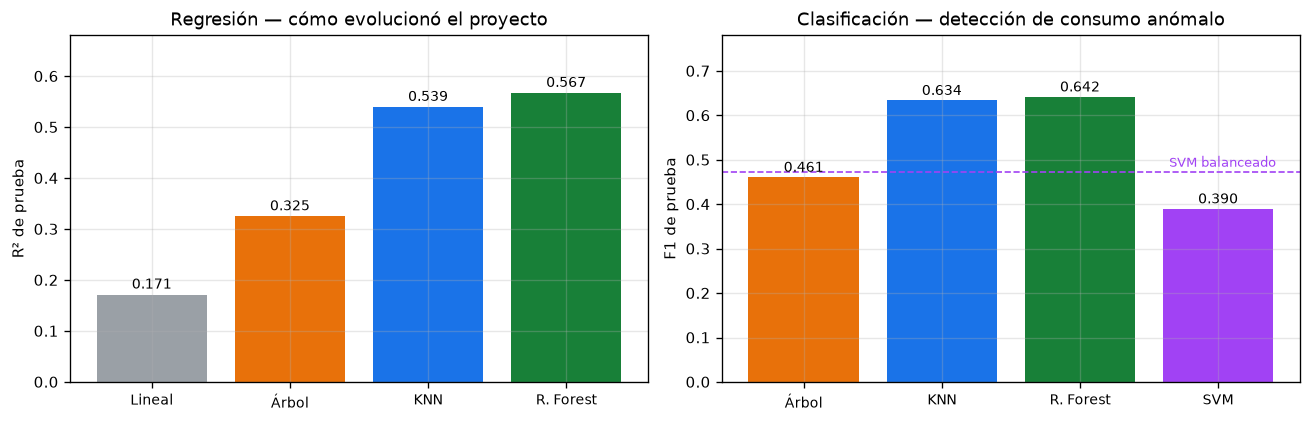

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

orden_r = ["Regresión Lineal", "Árbol", "KNN", "Random Forest"]
cols_r  = [COL["lin"], COL["arbol"], COL["knn"], COL["rf"]]
ax[0].bar(range(4), comp.loc[orden_r, "R² aleatoria"], color=cols_r)
for i, v in enumerate(comp.loc[orden_r, "R² aleatoria"]):
    ax[0].text(i, v + .012, f"{v:.3f}", ha="center", fontsize=8.5)
ax[0].set(xticks=range(4), ylim=(0, .68), ylabel="R² de prueba",
          title="Regresión — cómo evolucionó el proyecto")
ax[0].set_xticklabels(["Lineal", "Árbol", "KNN", "R. Forest"], fontsize=8.5)

orden_c = ["Árbol", "KNN", "Random Forest", "SVM"]
cols_c  = [COL["arbol"], COL["knn"], COL["rf"], COL["svm"]]
ax[1].bar(range(4), comp.loc[orden_c, "F1 aleatoria"], color=cols_c)
for i, v in enumerate(comp.loc[orden_c, "F1 aleatoria"]):
    ax[1].text(i, v + .012, f"{v:.3f}", ha="center", fontsize=8.5)
ax[1].axhline(f1_score(c_te, svm_b.predict(Xs_te)), ls="--", lw=1, color=COL["svm"])
ax[1].text(3.42, f1_score(c_te, svm_b.predict(Xs_te)) + .012, "SVM balanceado",
           fontsize=7.5, ha="right", color=COL["svm"])
ax[1].set(xticks=range(4), ylim=(0, .78), ylabel="F1 de prueba",
          title="Clasificación — detección de consumo anómalo")
ax[1].set_xticklabels(["Árbol", "KNN", "R. Forest", "SVM"], fontsize=8.5)
plt.tight_layout(); plt.savefig(FIG / "P1_evolucion.png"); plt.show()

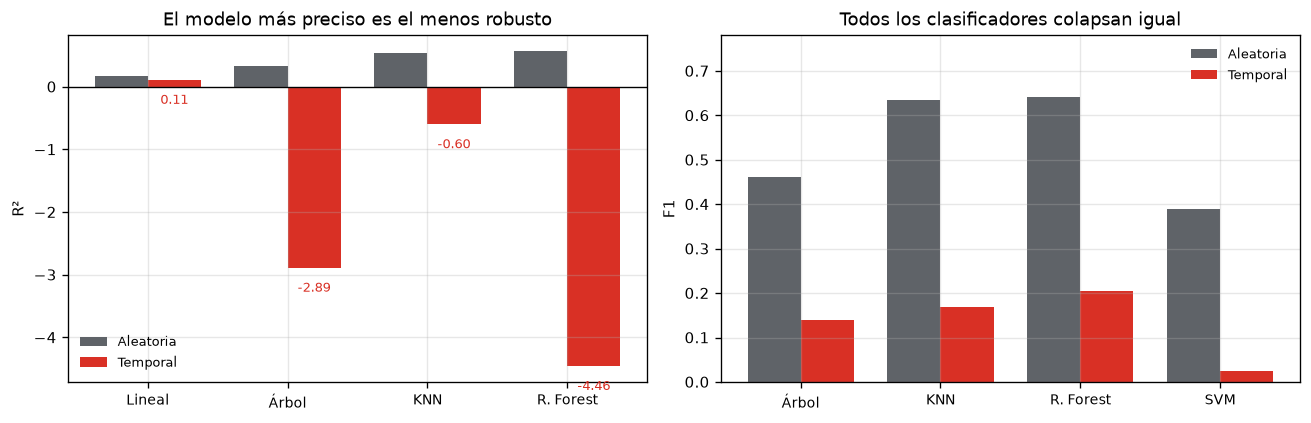

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
xx = np.arange(4)

ax[0].bar(xx - .19, comp.loc[orden_r, "R² aleatoria"], .38, label="Aleatoria", color="#5f6368")
ax[0].bar(xx + .19, comp.loc[orden_r, "R² temporal"],  .38, label="Temporal",  color=COL["alerta"])
ax[0].axhline(0, color="k", lw=.8)
for i, v in enumerate(comp.loc[orden_r, "R² temporal"]):
    ax[0].text(i + .19, v - .38, f"{v:.2f}", ha="center", fontsize=8, color=COL["alerta"])
ax[0].set(xticks=xx, ylabel="R²", title="El modelo más preciso es el menos robusto")
ax[0].set_xticklabels(["Lineal", "Árbol", "KNN", "R. Forest"], fontsize=8.5)
ax[0].legend(frameon=False, fontsize=8)

ax[1].bar(xx - .19, comp.loc[orden_c, "F1 aleatoria"], .38, label="Aleatoria", color="#5f6368")
ax[1].bar(xx + .19, comp.loc[orden_c, "F1 temporal"],  .38, label="Temporal",  color=COL["alerta"])
ax[1].set(xticks=xx, ylabel="F1", ylim=(0, .78), title="Todos los clasificadores colapsan igual")
ax[1].set_xticklabels(["Árbol", "KNN", "R. Forest", "SVM"], fontsize=8.5)
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "P1_aleatoria_vs_temporal.png"); plt.show()

### Qué cambia en el diseño de Shiro por causa de estos números

**Random Forest gana la partición aleatoria, pero no gana el puesto.** R² 0,567 contra 0,539 de KNN
es una ventaja de 0,028 — real pero estrecha. Y hay dos matices que la anulan para el uso que Shiro
le va a dar:

- **KNN detecta más anomalías que Random Forest** (recall 0,562 contra 0,522). En un sector donde
  el costo de no avisar es mayor que el de avisar de más, RF no es ganador absoluto.
- **Bajo partición temporal el orden se invierte por completo.** Es el resultado más importante de
  esta sección y conviene leerlo despacio:

| Modelo | R² aleatoria | R² temporal | Puesto que ocupa en cada una |
|---|---|---|---|
| Regresión Lineal | 0,171 | **+0,106** | último → **primero** |
| Árbol de Decisión | 0,325 | −2,891 | tercero → tercero |
| KNN | 0,539 | −0,602 | segundo → segundo |
| Random Forest | 0,567 | **−4,459** | **primero → último** |

**Un R² negativo significa que el modelo predice peor que decir siempre la media.** Tres de los
cuatro regresores caen ahí sobre el último mes. El único que sobrevive es **la regresión lineal**,
que en la partición aleatoria era el peor de todos: mantiene R² positivo (+0,106) y un MAE de
50,5 Wh frente a los 52,7 Wh de la línea base.

Ese +0,106 es poco —explica una décima parte de la varianza— pero es la única señal del dataset que
**sobrevive al paso del tiempo**. Todo lo demás que los modelos más capaces aprenden resulta ser
estructura del invierno belga que no se repite en mayo. La sección 2.4 investiga si esa señal se
puede ampliar, porque de ella depende que exista o no una función de transición para el gemelo.

---
# Punto 2 — Análisis de errores críticos

**Decisión de Shiro que depende de esto:** la recompensa del MDP es
`r = −(energía × tarifa) − λ · desviación de confort`. Si el simulador subestima el consumo, el
primer término sale barato y el agente cobra un **ahorro que no existe**. Este punto localiza dónde
miente el gemelo y cuánto.

## 2.1 Identificación de errores — dónde se rompe el modelo

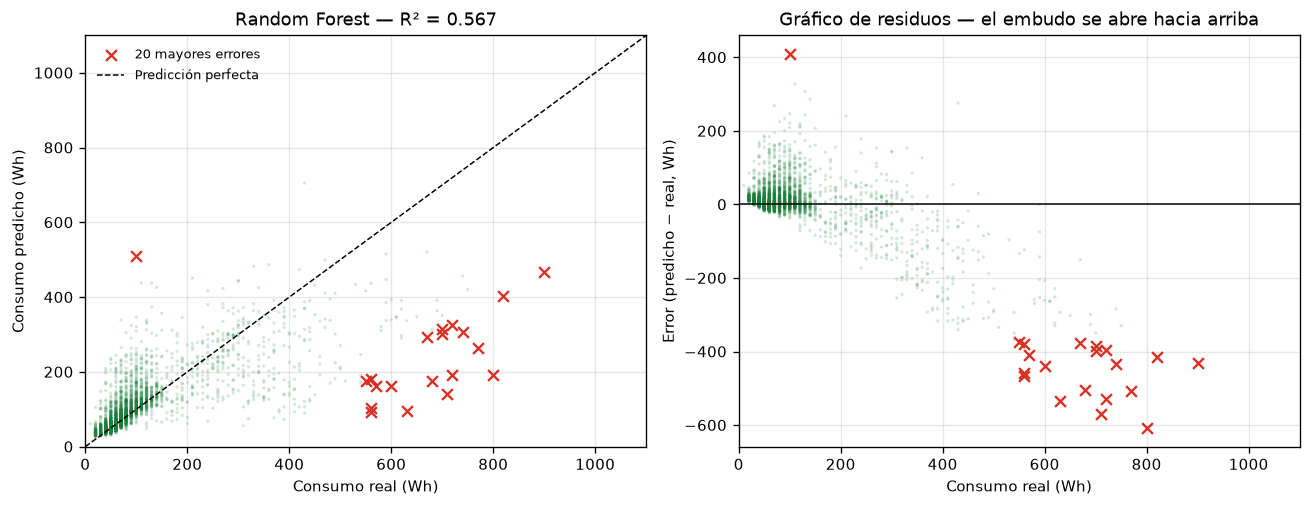

               date  Appliances  pred    err  hora         franja  es_fin_semana  lights
2016-04-16 10:40:00         800 192.2 -607.8    10 Mañana (06-12)              1       0
2016-02-08 11:10:00         710 141.4 -568.6    11 Mañana (06-12)              0      20
2016-05-07 18:20:00         630  96.2 -533.8    18  Noche (18-24)              1       0
2016-04-04 11:00:00         720 192.1 -527.9    11 Mañana (06-12)              0      10
2016-02-25 11:00:00         770 264.1 -505.9    11 Mañana (06-12)              0      20
2016-02-12 11:50:00         680 175.2 -504.9    11 Mañana (06-12)              0       0
2016-05-13 07:50:00         560  93.7 -466.4     7 Mañana (06-12)              0       0
2016-03-21 18:40:00         560 102.2 -457.8    18  Noche (18-24)              0      30
2016-05-13 11:10:00         600 162.1 -437.9    11 Mañana (06-12)              0      20
2016-02-15 10:20:00         740 307.1 -432.9    10 Mañana (06-12)              0      20
2016-04-04 15:40:00  

In [8]:
ev = df.loc[X_te.index, ["date", "Appliances", "hora", "franja", "es_fin_semana", "mes", "lights"]].copy()
ev["pred"] = pred_rf
ev["err"] = ev.pred - ev.Appliances
ev["abs_err"] = ev.err.abs()
top20 = ev.sort_values("abs_err", ascending=False).head(20)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].scatter(ev.Appliances, ev.pred, s=4, alpha=.18, edgecolors="none", color=COL["rf"])
ax[0].scatter(top20.Appliances, top20.pred, s=42, color=COL["alerta"], marker="x", lw=1.4,
              label="20 mayores errores", zorder=3)
ax[0].plot([0, 1100], [0, 1100], "k--", lw=.9, label="Predicción perfecta")
ax[0].set(xlim=(0, 1100), ylim=(0, 1100), xlabel="Consumo real (Wh)",
          ylabel="Consumo predicho (Wh)", title=f"Random Forest — R² = {r2_score(y_te, pred_rf):.3f}")
ax[0].legend(frameon=False, loc="upper left", fontsize=8)

ax[1].scatter(ev.Appliances, ev.err, s=4, alpha=.18, edgecolors="none", color=COL["rf"])
ax[1].scatter(top20.Appliances, top20.err, s=42, color=COL["alerta"], marker="x", lw=1.4, zorder=3)
ax[1].axhline(0, color="k", lw=.9)
ax[1].set(xlim=(0, 1100), xlabel="Consumo real (Wh)", ylabel="Error (predicho − real, Wh)",
          title="Gráfico de residuos — el embudo se abre hacia arriba")
plt.tight_layout(); plt.savefig(FIG / "P2_dispersion.png"); plt.show()

print(top20[["date", "Appliances", "pred", "err", "hora", "franja", "es_fin_semana", "lights"]]
      .to_string(index=False, formatters={"pred": "{:.1f}".format, "err": "{:.1f}".format}))
print(f"\nDe los 20 mayores errores: real medio {top20.Appliances.mean():.0f} Wh, "
      f"predicho medio {top20.pred.mean():.0f} Wh")
print(f"Franja: {top20.franja.value_counts().to_dict()}")
print(f"Subestimaciones: {(top20.err < 0).sum()} de 20")

**El error no es ruido: es sesgo, y tiene una sola dirección.** 19 de los 20 mayores errores son
subestimaciones — el modelo predice 243 Wh de media donde la casa consumió 653. El gráfico de
residuos lo confirma: el embudo se abre hacia arriba, es decir, cuanto más alto el consumo real,
más se queda corto el modelo. La mitad de esos 20 casos ocurre en la **mañana (06–12 h)**, el tramo
de rutina más variable.

## 2.2 El error tampoco es uniforme a lo largo del día

ERROR POR FRANJA HORARIA (Random Forest)
                      n    MAE  sesgo  real_medio
franja                                           
Madrugada (00-06)   972   7.34  -0.08       50.49
Mañana (06-12)      994  42.12  -0.20       98.74
Noche (18-24)       969  34.74   2.99      114.58
Tarde (12-18)      1012  38.16   2.98      121.86

ERROR POR CUARTIL DE CONSUMO REAL
                  n    MAE  sesgo
cuartil                          
Q1 (más bajo)  1508  12.06   9.77
Q2              619  13.79   6.22
Q3              979  27.63  21.60
Q4 (más alto)   841  80.27 -40.55


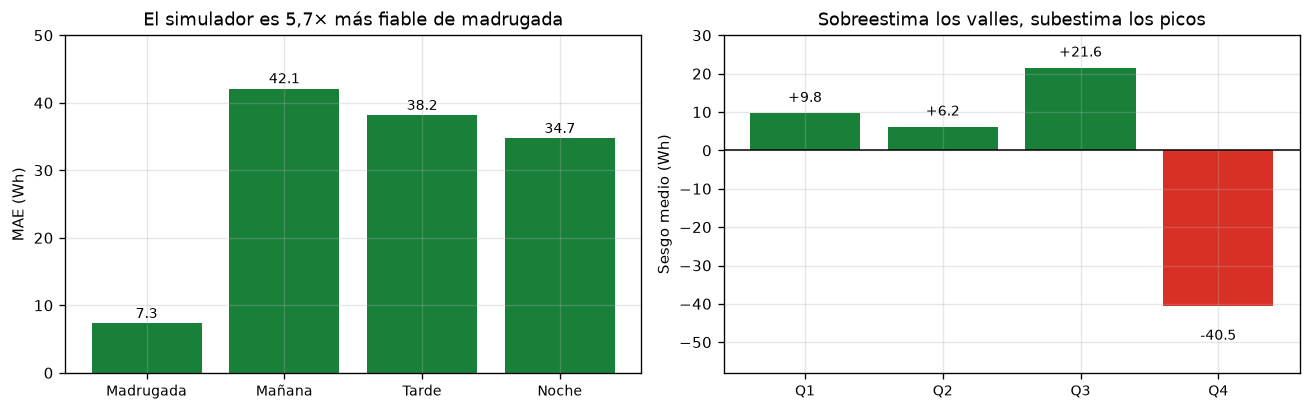

In [9]:
por_franja = ev.groupby("franja").agg(n=("abs_err", "size"), MAE=("abs_err", "mean"),
                                      sesgo=("err", "mean"), real_medio=("Appliances", "mean"))
ev["cuartil"] = pd.qcut(ev.Appliances, 4, labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"])
por_cuartil = ev.groupby("cuartil", observed=True).agg(n=("err", "size"), MAE=("abs_err", "mean"),
                                                       sesgo=("err", "mean"))
print("ERROR POR FRANJA HORARIA (Random Forest)"); print(por_franja.round(2).to_string())
print("\nERROR POR CUARTIL DE CONSUMO REAL");        print(por_cuartil.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ordf = ["Madrugada (00-06)", "Mañana (06-12)", "Tarde (12-18)", "Noche (18-24)"]
ax[0].bar(range(4), por_franja.loc[ordf, "MAE"], color=COL["rf"])
for i, v in enumerate(por_franja.loc[ordf, "MAE"]):
    ax[0].text(i, v + .8, f"{v:.1f}", ha="center", fontsize=8.5)
ax[0].set(xticks=range(4), ylabel="MAE (Wh)", ylim=(0, 50),
          title="El simulador es 5,7× más fiable de madrugada")
ax[0].set_xticklabels(["Madrugada", "Mañana", "Tarde", "Noche"], fontsize=8.5)

cu = por_cuartil["sesgo"]
ax[1].bar(range(4), cu, color=[COL["rf"] if v > 0 else COL["alerta"] for v in cu])
for i, v in enumerate(cu):
    ax[1].text(i, v + (2 if v > 0 else -6), f"{v:+.1f}", ha="center", fontsize=8.5,
               va="bottom" if v > 0 else "top")
ax[1].axhline(0, color="k", lw=.9)
ax[1].set(xticks=range(4), ylim=(-58, 30), ylabel="Sesgo medio (Wh)",
          title="Sobreestima los valles, subestima los picos")
ax[1].set_xticklabels(["Q1", "Q2", "Q3", "Q4"], fontsize=8.5)
plt.tight_layout(); plt.savefig(FIG / "P2_error_franja.png"); plt.show()

**Dos sesgos que el gemelo digital tiene que declarar.**

El MAE va de **7,3 Wh en la madrugada a 42,1 Wh en la mañana**: el simulador es casi seis veces más
fiable cuando la casa duerme. Y por cuartil de consumo el signo se invierte: sobreestima los tres
cuartiles bajos (+9,8 / +6,2 / +21,6 Wh) y subestima el alto (**−40,6 Wh**).

Si el gemelo declarara una sola incertidumbre global, el agente creería que la tarde es tan
predecible como la madrugada y explotaría exactamente las horas donde el simulador es menos fiable.
**La incertidumbre del entorno debe ser una función de la franja horaria, no una constante.**

## 2.3 Tres casos críticos

Se eligen tres casos que no son "los tres peores" sino los tres que fallan **por razones distintas**.

In [10]:
CASOS = {13786: "Caso A — el pico invisible",
         3997:  "Caso B — el proxy de ocupación estaba encendido",
         12086: "Caso C — la falsa alarma"}

def ficha(idx):
    r = df.loc[idx]
    p = float(ev.loc[idx, "pred"]); real = float(r.Appliances)
    print("=" * 78)
    print(f"{CASOS[idx]}   ·   índice {idx}")
    print("=" * 78)
    print(f"  Fecha y hora ....... {r.date}  ({'fin de semana' if r.es_fin_semana else 'día laboral'}, {r.franja})")
    print(f"  Consumo REAL ....... {real:.0f} Wh")
    print(f"  Predicción RF ...... {p:.1f} Wh")
    print(f"  Error .............. {p - real:+.1f} Wh  ({abs(p - real) / real * 100:.0f} % del valor real)")
    print(f"  lights ............. {r.lights:.0f}")
    print(f"  Temperaturas int ... " + " ".join(f"T{i}={r[f'T{i}']:.1f}" for i in range(1, 10)))
    print(f"  Humedades int ...... " + " ".join(f"RH{i}={r[f'RH_{i}']:.0f}" for i in range(1, 10)))
    print(f"  Clima exterior ..... T_out={r.T_out:.1f} °C · RH_out={r.RH_out:.0f} % · "
          f"Press={r.Press_mm_hg:.0f} mm Hg · Viento={r.Windspeed:.1f}")
    ventana = df[(df.date >= r.date - pd.Timedelta(hours=1)) & (df.date <= r.date + pd.Timedelta(hours=1))]
    print(f"  Consumo ±1 h ....... {list(ventana.Appliances.astype(int))}")
    print(f"  Percentil del real . {(df.Appliances < real).mean() * 100:.1f} % de las lecturas están por debajo")
    print()

for i in CASOS: ficha(i)

Caso A — el pico invisible   ·   índice 13786
  Fecha y hora ....... 2016-04-16 10:40:00  (fin de semana, Mañana (06-12))
  Consumo REAL ....... 800 Wh
  Predicción RF ...... 192.2 Wh
  Error .............. -607.8 Wh  (76 % del valor real)
  lights ............. 0
  Temperaturas int ... T1=22.1 T2=21.2 T3=23.2 T4=21.7 T5=20.8 T6=10.3 T7=21.1 T8=22.6 T9=21.1
  Humedades int ...... RH1=42 RH2=42 RH3=38 RH4=40 RH5=47 RH6=50 RH7=36 RH8=43 RH9=45
  Clima exterior ..... T_out=10.4 °C · RH_out=78 % · Press=746 mm Hg · Viento=5.7
  Consumo ±1 h ....... [70, 50, 50, 80, 80, 230, 800, 510, 380, 330, 310, 340, 230]
  Percentil del real . 99.9 % de las lecturas están por debajo

Caso B — el proxy de ocupación estaba encendido   ·   índice 3997
  Fecha y hora ....... 2016-02-08 11:10:00  (día laboral, Mañana (06-12))
  Consumo REAL ....... 710 Wh
  Predicción RF ...... 141.4 Wh
  Error .............. -568.6 Wh  (80 % del valor real)
  lights ............. 20
  Temperaturas int ... T1=20.8 T2=20.0 T

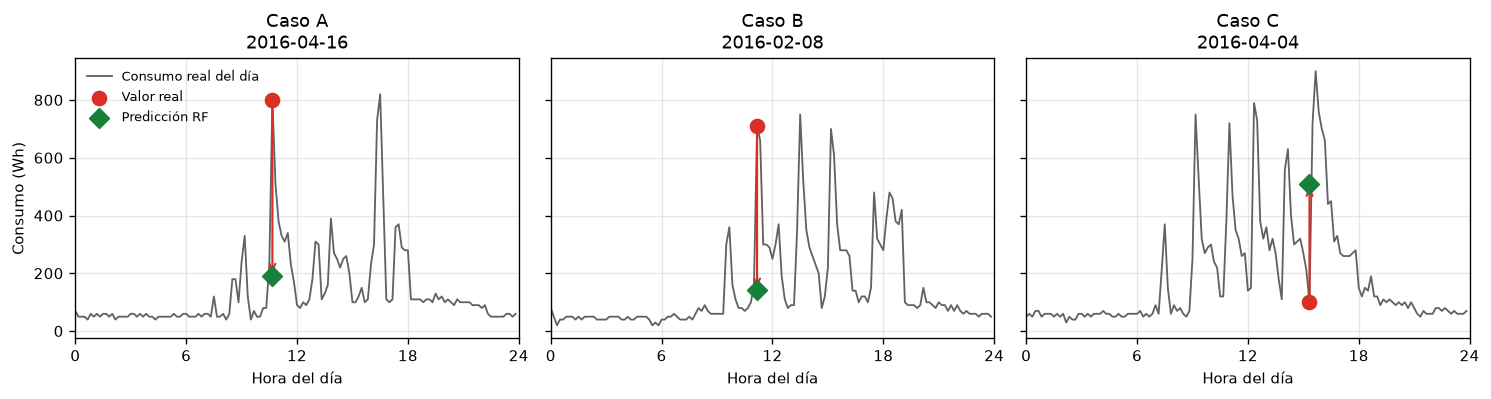

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
for k, (idx, titulo) in enumerate(CASOS.items()):
    r = df.loc[idx]
    dia = df[df.date.dt.date == r.date.date()]
    ax[k].plot(dia.date.dt.hour + dia.date.dt.minute / 60, dia.Appliances,
               color="#5f6368", lw=1.1, label="Consumo real del día")
    hx = r.date.hour + r.date.minute / 60
    ax[k].scatter([hx], [r.Appliances], s=70, color=COL["alerta"], zorder=5, label="Valor real")
    ax[k].scatter([hx], [ev.loc[idx, "pred"]], s=70, color=COL["rf"], marker="D", zorder=5,
                  label="Predicción RF")
    ax[k].annotate("", xy=(hx, ev.loc[idx, "pred"]), xytext=(hx, r.Appliances),
                   arrowprops=dict(arrowstyle="->", color=COL["alerta"], lw=1.3))
    ax[k].set(xlim=(0, 24), xticks=[0, 6, 12, 18, 24], xlabel="Hora del día",
              title=f"{titulo.split('—')[0].strip()}\n{r.date.date()}")
    if k == 0:
        ax[k].set_ylabel("Consumo (Wh)"); ax[k].legend(frameon=False, fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "P2_casos.png"); plt.show()

### Análisis individual

**Caso A — el pico invisible** · 16-abr, 10:40, sábado · real **800 Wh**, predicho **192 Wh**
(error −608 Wh, el mayor del conjunto de prueba).
Las 29 entradas describen una casa perfectamente ordinaria: 22,1 °C en la sala, humedades entre
36 % y 50 %, 10,4 °C fuera, y **`lights = 0`**. Ninguna variable anuncia el pico. En la hora
anterior el consumo iba entre 50 y 100 Wh; a las 10:40 salta a 800 y a los 10 minutos vuelve a
bajar. *¿Qué feature influyó en el error?* Ninguna — el problema es la que **falta**: alguien
encendió un electrodoméstico de alta potencia y esa decisión no está en ninguna columna.
*¿Sobreajuste?* No. El modelo predijo el valor sensato dado lo que veía; el sábado por la mañana con
las luces apagadas, 192 Wh es la respuesta correcta en promedio. Es **error irreducible con estas
variables**, no memorización.

**Caso B — el proxy de ocupación estaba encendido** · 8-feb, 11:10, lunes · real **710 Wh**,
predicho **141 Wh** (error −569 Wh).
Aquí sí había señal: **`lights = 20`**, y en el Taller 2 el árbol había identificado `lights` como el
proxy de ocupación que el dataset no trae etiquetado. El modelo la tenía delante y no la usó lo
suficiente — `lights` pesa solo **2,9 %** de la importancia total en Random Forest. *¿Feature que
influyó?* `lights`, por defecto de peso. *¿Sobreajuste?* Tampoco: con `min_samples_leaf = 1` el
bosque memoriza el entrenamiento (R² train 0,938), pero eso no explica este fallo — el patrón
"luces encendidas a media mañana ⇒ pico" simplemente es demasiado poco frecuente para dominar el
promedio de 200 árboles. Es **subajuste de una relación minoritaria**, el problema opuesto.

**Caso C — la falsa alarma** · 4-abr, 15:20, lunes · real **100 Wh**, predicho **509 Wh**
(error **+409 Wh**, el único gran error en la dirección contraria).
Es el caso más informativo de los tres. Todo apuntaba a consumo alto: `T3 = 26,2 °C` — la
temperatura interior más alta de los tres casos y muy por encima de la media de la casa —,
`T8 = 24,6 °C`, y una tarde de lunes, la franja de mayor consumo. Y sin embargo la casa consumió
100 Wh. Veinte minutos después, a las 15:40, el consumo real llegó a **900 Wh**: el pico existía,
pero el modelo lo puso **20 minutos antes de tiempo**. *¿Feature que influyó?* `T3` y `hora`.
*¿Sobreajuste?* Este es el único de los tres donde la respuesta se acerca a sí: el modelo aprendió
una asociación "habitación caliente + tarde ⇒ consumo alto" que es válida en promedio pero que aquí
aplicó con una precisión temporal que no tiene. Para Shiro es el caso más caro: **una falsa alarma
enviada al teléfono de una persona**.

### ¿Los tres modelos fallan en los mismos sitios?

In [12]:
comp_casos = pd.DataFrame({
    "Real (Wh)": [df.loc[i, "Appliances"] for i in CASOS],
    "Árbol": [pred_arbol[list(X_te.index).index(i)] for i in CASOS],
    "KNN": [pred_knn[list(X_te.index).index(i)] for i in CASOS],
    "Random Forest": [pred_rf[list(X_te.index).index(i)] for i in CASOS],
}, index=[f"{v.split('—')[0].strip()} (idx {k})" for k, v in CASOS.items()])
print(comp_casos.round(1).to_string())
print("\nLos tres modelos fallan en la misma dirección y con magnitud parecida:")
print("el problema no es el algoritmo, es la información disponible.")

                    Real (Wh)  Árbol    KNN  Random Forest
Caso A (idx 13786)        800  115.7  303.9          192.2
Caso B (idx 3997)         710  108.4  159.2          141.4
Caso C (idx 12086)        100  550.0  603.0          508.8

Los tres modelos fallan en la misma dirección y con magnitud parecida:
el problema no es el algoritmo, es la información disponible.


## 2.4 Propuesta de mejora — medida, no afirmada

El enunciado pide sugerir una técnica de mejora. En vez de proponerla, se prueba.

La variable que falta es *"qué aparato está encendido"*, y no existe forma de obtenerla del dataset.
Pero hay una aproximación disponible: **el propio consumo de los intervalos anteriores**. Si hace
diez minutos la casa consumía 600 Wh, es muy probable que siga consumiendo mucho ahora.

Las variables de retardo solo son legítimas bajo **partición temporal**: al predecir el futuro, el
pasado ya se conoce. Bajo partición aleatoria filtrarían masivamente (el vecino de diez minutos está
en el conjunto de entrenamiento), así que se evalúan únicamente en la temporal, que además es la
partición donde el proyecto tiene su problema real.

In [13]:
dl = dfo.copy()
for k in (1, 2, 3, 6):
    dl[f"lag{k}"] = dl[TARGET].shift(k)          # 10, 20, 30 y 60 minutos antes
dl["media_1h"] = dl[TARGET].shift(1).rolling(6).mean()
dl["max_1h"]   = dl[TARGET].shift(1).rolling(6).max()
dl["std_1h"]   = dl[TARGET].shift(1).rolling(6).std()
dl = dl.dropna().reset_index(drop=True)
cl = int(len(dl) * .8)
RETARDOS = ["lag1", "lag2", "lag3", "lag6", "media_1h", "max_1h", "std_1h"]

conjuntos = {"Base — 29 variables": FEATURES,
             "+ lag1 (hace 10 min)": FEATURES + ["lag1"],
             "+ lag1..lag3 (media hora)": FEATURES + ["lag1", "lag2", "lag3"],
             "+ retardos completos": FEATURES + RETARDOS}
filas = []
for nombre, cols in conjuntos.items():
    Xa, ya_ = dl.iloc[:cl][cols], dl.iloc[:cl][TARGET]
    Xb, yb_ = dl.iloc[cl:][cols], dl.iloc[cl:][TARGET]
    m = RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xa, ya_)
    p = m.predict(Xb)
    ca_, cb_ = (ya_ > UMBRAL).astype(int), (yb_ > UMBRAL).astype(int)
    mc = RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xa, ca_)
    pc = mc.predict(Xb)
    filas.append({"conjunto": nombre, "n_vars": len(cols),
                  "R² temporal": r2_score(yb_, p), "MAE (Wh)": mean_absolute_error(yb_, p),
                  "Recall": recall_score(cb_, pc), "F1": f1_score(cb_, pc, zero_division=0)})
tabla_lags = pd.DataFrame(filas).set_index("conjunto")
mae_base = mean_absolute_error(dl.iloc[cl:][TARGET],
                               np.full(len(dl) - cl, dl.iloc[:cl][TARGET].mean()))
print("EFECTO DE LAS VARIABLES DE RETARDO — Random Forest, partición temporal")
print(tabla_lags.round(3).to_string())
print(f"\nLínea base temporal (predecir siempre la media del entrenamiento): MAE = {mae_base:.2f} Wh")

m = RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1).fit(
    dl.iloc[:cl][FEATURES + RETARDOS], dl.iloc[:cl][TARGET])
imp_l = pd.Series(m.feature_importances_, index=FEATURES + RETARDOS).sort_values(ascending=False)
print(f"\nPeso del bloque de retardos: {imp_l[RETARDOS].sum()*100:.1f} % "
      f"(solo lag1: {imp_l['lag1']*100:.1f} %)")

EFECTO DE LAS VARIABLES DE RETARDO — Random Forest, partición temporal
                           n_vars  R² temporal  MAE (Wh)  Recall     F1
conjunto                                                               
Base — 29 variables            29       -4.582   175.765   0.176  0.167
+ lag1 (hace 10 min)           30       -0.716    86.812   0.259  0.302
+ lag1..lag3 (media hora)      32       -0.545    80.571   0.426  0.504
+ retardos completos           36       -0.484    76.197   0.571  0.580

Línea base temporal (predecir siempre la media del entrenamiento): MAE = 52.65 Wh



Peso del bloque de retardos: 71.0 % (solo lag1: 60.5 %)


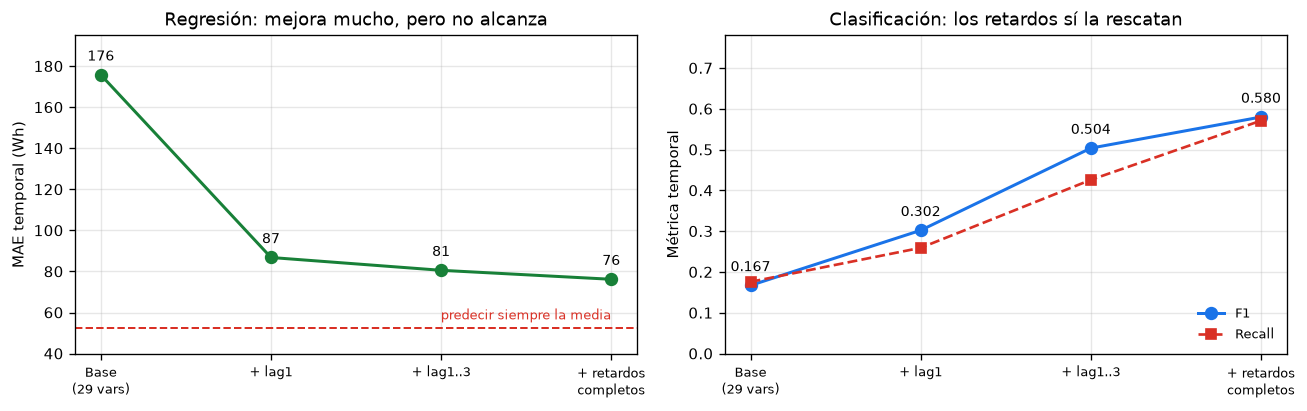

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
et = ["Base\n(29 vars)", "+ lag1", "+ lag1..3", "+ retardos\ncompletos"]

ax[0].plot(range(4), tabla_lags["MAE (Wh)"], "o-", color=COL["rf"], lw=1.8, ms=7)
ax[0].axhline(mae_base, ls="--", lw=1.2, color=COL["alerta"])
ax[0].text(3, mae_base + 4, "predecir siempre la media", fontsize=7.5, ha="right", color=COL["alerta"])
for i, v in enumerate(tabla_lags["MAE (Wh)"]):
    ax[0].text(i, v + 7, f"{v:.0f}", ha="center", fontsize=8.5)
ax[0].set(xticks=range(4), ylabel="MAE temporal (Wh)", ylim=(40, 195),
          title="Regresión: mejora mucho, pero no alcanza")
ax[0].set_xticklabels(et, fontsize=8)

ax[1].plot(range(4), tabla_lags["F1"], "o-", color=COL["knn"], lw=1.8, ms=7, label="F1")
ax[1].plot(range(4), tabla_lags["Recall"], "s--", color=COL["alerta"], lw=1.6, ms=6, label="Recall")
for i, v in enumerate(tabla_lags["F1"]):
    ax[1].text(i, v + .035, f"{v:.3f}", ha="center", fontsize=8.5)
ax[1].set(xticks=range(4), ylabel="Métrica temporal", ylim=(0, .78),
          title="Clasificación: los retardos sí la rescatan")
ax[1].set_xticklabels(et, fontsize=8)
ax[1].legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(FIG / "P2_retardos.png"); plt.show()

### Resultado parcial: el clasificador se rescata, el regresor no

**El clasificador se rescata.** F1 temporal pasa de **0,167 a 0,580** y el recall de **0,176 a
0,571** — de detectar menos de dos anomalías de cada diez a detectar casi seis, sobre un mes que el
modelo nunca vio. Es la mejora más grande obtenida en todo el corte, y no vino de cambiar de
algoritmo ni de ajustar hiperparámetros: vino de **añadir una variable**.

**El regresor no se rescata.** El MAE temporal baja de 175,8 a 76,2 Wh —una reducción del 57 %—
pero sigue siendo **peor que predecir siempre la media** (52,7 Wh) y el R² sigue negativo (−0,484).
Los retardos explican el 71 % de la importancia del modelo y aun así no bastan.

Antes de concluir que la función de transición del gemelo es imposible, conviene probar una cosa
más. Random Forest fue el ganador de la partición aleatoria, pero el punto 1 mostró que ahí el orden
se invierte. **¿Y si el problema no son los retardos sino el bosque?**

### 2.5 El mismo experimento, con el modelo que quedó último

In [15]:
COLS_L = FEATURES + RETARDOS
Xa, Xb = dl.iloc[:cl][COLS_L], dl.iloc[cl:][COLS_L]
ya_, yb_ = dl.iloc[:cl][TARGET], dl.iloc[cl:][TARGET]

comparativa = []
for nombre, modelo in [("Random Forest", RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1)),
                       ("Regresión Lineal", LinearRegression())]:
    p = modelo.fit(Xa, ya_).predict(Xb)
    comparativa.append({"Modelo": nombre, "R² temporal": r2_score(yb_, p),
                        "MAE (Wh)": mean_absolute_error(yb_, p),
                        "RMSE (Wh)": float(np.sqrt(mean_squared_error(yb_, p))),
                        "Sesgo medio (Wh)": float((p - yb_).mean()),
                        "Predicción media (Wh)": float(p.mean())})
comparativa.append({"Modelo": "— Línea base (media)", "R² temporal": 0.0,
                    "MAE (Wh)": mae_base, "RMSE (Wh)": float(np.sqrt(mean_squared_error(
                        yb_, np.full(len(yb_), ya_.mean())))),
                    "Sesgo medio (Wh)": float(ya_.mean() - yb_.mean()),
                    "Predicción media (Wh)": float(ya_.mean())})
tabla_lin = pd.DataFrame(comparativa).set_index("Modelo")
print("REGRESIÓN CON RETARDOS — partición temporal (36 variables, mes nunca visto)")
print(tabla_lin.round(3).to_string())
print(f"\nConsumo real del mes de prueba: media {yb_.mean():.2f} Wh · máximo {yb_.max():.0f} Wh")
print(f"Consumo del entrenamiento:      media {ya_.mean():.2f} Wh · máximo {ya_.max():.0f} Wh")
print("\nPara comparar: el MEJOR resultado de todo el proyecto en partición ALEATORIA")
print(f"era Random Forest con R² 0,567 · MAE 30,73 Wh.")

REGRESIÓN CON RETARDOS — partición temporal (36 variables, mes nunca visto)
                      R² temporal  MAE (Wh)  RMSE (Wh)  Sesgo medio (Wh)  Predicción media (Wh)
Modelo                                                                                         
Random Forest              -0.484    76.197    110.797            63.853                160.161
Regresión Lineal            0.557    28.166     60.543             0.457                 96.764
— Línea base (media)        0.000    52.645     90.963             1.750                 98.058

Consumo real del mes de prueba: media 96.31 Wh · máximo 850 Wh
Consumo del entrenamiento:      media 98.06 Wh · máximo 1080 Wh

Para comparar: el MEJOR resultado de todo el proyecto en partición ALEATORIA
era Random Forest con R² 0,567 · MAE 30,73 Wh.


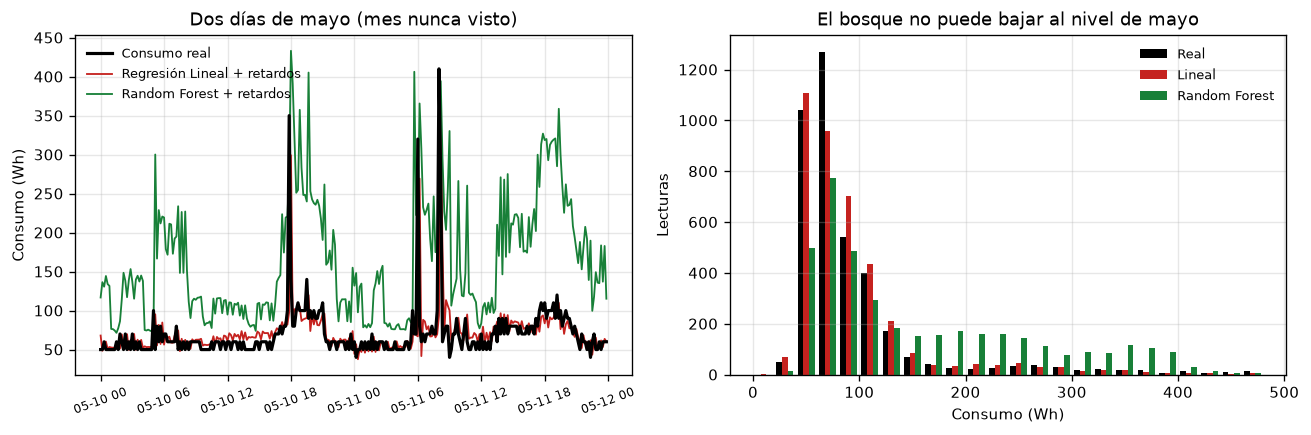

Predicción media — real 96.3 Wh · lineal 96.8 Wh · bosque 160.2 Wh
Sesgo del bosque: +63.9 Wh sobre TODO el mes.

Coeficientes lineales dominantes (variables estandarizadas):
lag1      79.03
max_1h    29.37
lag2     -20.43
std_1h   -15.66
T1       -13.04


In [16]:
# ¿Por qué la lineal aguanta y el bosque no? El rango de valores que cada uno puede devolver.
rf_l  = RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xa, ya_)
lin_l = LinearRegression().fit(Xa, ya_)
p_rf, p_lin = rf_l.predict(Xb), lin_l.predict(Xb)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))
h = pd.Timestamp("2016-05-10")
vent = (dl.iloc[cl:]["date"] >= h) & (dl.iloc[cl:]["date"] < h + pd.Timedelta(days=2))
t_ = dl.iloc[cl:].loc[vent, "date"]
ax[0].plot(t_, yb_[vent.values], color="black", lw=1.9, label="Consumo real", zorder=3)
ax[0].plot(t_, p_lin[vent.values], color="#c5221f", lw=1.1, label="Regresión Lineal + retardos")
ax[0].plot(t_, p_rf[vent.values],  color=COL["rf"],  lw=1.1, label="Random Forest + retardos")
ax[0].set(ylabel="Consumo (Wh)", title="Dos días de mayo (mes nunca visto)")
ax[0].tick_params(axis="x", labelsize=7, rotation=20)
ax[0].legend(frameon=False, fontsize=7.5)

ax[1].hist([yb_, p_lin, p_rf], bins=24, range=(0, 480),
           label=["Real", "Lineal", "Random Forest"],
           color=["black", "#c5221f", COL["rf"]])
ax[1].set(xlabel="Consumo (Wh)", ylabel="Lecturas",
          title="El bosque no puede bajar al nivel de mayo")
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "P2_lineal_vs_bosque.png"); plt.show()

print(f"Predicción media — real {yb_.mean():.1f} Wh · lineal {p_lin.mean():.1f} Wh · "
      f"bosque {p_rf.mean():.1f} Wh")
print(f"Sesgo del bosque: {(p_rf - yb_).mean():+.1f} Wh sobre TODO el mes.")
sc_tmp = StandardScaler().fit(Xa)
coef = pd.Series(LinearRegression().fit(sc_tmp.transform(Xa), ya_).coef_,
                 index=COLS_L).sort_values(key=abs, ascending=False)
print("\nCoeficientes lineales dominantes (variables estandarizadas):")
print(coef.head(5).round(2).to_string())

### El resultado que reordena el proyecto

**La función de transición del gemelo digital sí se puede construir. No con el modelo que ganó.**

| Modelo (temporal, con retardos) | R² | MAE | RMSE |
|---|---|---|---|
| Random Forest | −0,484 | 76,20 Wh | 110,80 Wh |
| **Regresión Lineal** | **+0,557** | **28,17 Wh** | **60,54 Wh** |
| Línea base (media) | 0,000 | 52,65 Wh | 90,96 Wh |

La regresión lineal con retardos alcanza **R² 0,557 y MAE 28,17 Wh sobre un mes que nunca vio**.
Para dimensionarlo: el mejor resultado de todo el proyecto hasta ahora era Random Forest con R²
0,567 y MAE 30,73 Wh — **y eso era con partición aleatoria**, la fácil, la que filtra vecinos de diez
minutos entre entrenamiento y prueba. La lineal iguala ese resultado en la partición difícil.

**El mecanismo es la extrapolación.** Random Forest predice promediando valores que vio en
entrenamiento: no puede devolver un nivel de consumo que no exista en los datos de invierno. Sobre
mayo predice una media de **160 Wh cuando la realidad es 96** — un sesgo de **+64 Wh sostenido
durante todo el mes**, visible en el histograma: la distribución verde está desplazada a la derecha y
no llega a poblar la zona baja. La regresión lineal, dominada por `lag1` (coeficiente 79,0 sobre
variables estandarizadas), no predice un nivel: predice un **cambio respecto del nivel actual**, y
eso se traslada intacto a un régimen nuevo. Su sesgo medio es de **+0,5 Wh**.

> **Lo que esto significa para Shiro.** El gemelo digital **sí es viable**, y la decisión de
> arquitectura cambia por completo: la función de transición se implementa con **regresión lineal
> sobre variables de retardo**, no con Random Forest. El modelo que la tabla de métricas coronaba es
> justamente el que no sirve para simular, porque un simulador tiene que funcionar en condiciones que
> no estaban en los datos — y eso es precisamente lo que un bosque no sabe hacer.
>
> Hay una condición: el simulador necesita conocer el consumo reciente para dar el paso siguiente.
> Eso es exactamente cómo funciona un entorno de refuerzo —el estado incluye el consumo reciente, tal
> como ya lo definía la propuesta— así que la restricción encaja con el diseño en lugar de romperlo.

### Las cuatro preguntas del enunciado

**¿En algún punto reentrenaron el modelo? ¿Por qué?** Sí, tres veces y por tres razones distintas.
(1) En el Taller 2, el árbol se reentrenó a lo largo de un barrido de profundidad al ver que
`max_depth` sin límite daba R² train = 1,000 y test = 0,253. (2) En el Taller 3 se reentrenó Random
Forest 16 veces en un barrido secuencial, y el resultado invirtió la lección anterior: **la
regularización que un árbol individual necesita perjudica al bosque** — subir `min_samples_leaf` de
1 a 20 hunde el R² de 0,567 a 0,395, porque el bagging obtiene su regularización del promedio y no
de la poda. (3) En este parcial se reentrenó todo bajo partición temporal con retardos.

**¿Hicieron ingeniería de variables? ¿Cuál funcionó mejor?** Tres rondas, y la respuesta es
inequívoca. Las **4 variables temporales** derivadas de la marca de tiempo fueron la primera:
`hora` sola pesa 24,7 % en el árbol y 15,2 % en el bosque, y es la raíz del árbol. `lights` como
**proxy de ocupación** fue la segunda, aunque su peso resultó menor de lo esperado (2,9 %).

Pero **la que funcionó mejor, sin comparación, son las variables de retardo**. Convirtieron un
clasificador inservible sobre datos futuros (F1 0,167) en uno utilizable (0,580), y —combinadas con
regresión lineal— convirtieron un regresor peor que la media (R² −4,58) en el mejor modelo del
proyecto sobre la partición difícil (R² +0,557). Ninguna búsqueda de hiperparámetros de los tres
talleres produjo una mejora ni remotamente comparable. **La lección es que el techo estaba en la
información disponible, no en el algoritmo** — exactamente lo que el análisis de los tres casos
críticos había anticipado.

**¿Tuvieron que balancear clases? ¿Con qué técnica?** Sí. Las anomalías son el 9,6 % de los datos, y
decir siempre "normal" ya da 0,904 de accuracy con F1 = 0,000 — por eso el proyecto reporta Recall y
F1, nunca accuracy. En el SVM el desbalance era fatal: **6 de 9 combinaciones de kernel y C
colapsaron al clasificador trivial**. La técnica aplicada fue `class_weight='balanced'`, que pondera
el error de cada clase por el inverso de su frecuencia sin duplicar ni descartar filas. El resultado:
recall de 0,285 a **0,662** y F1 de 0,390 a 0,472, a costa de que la precisión cayera a 0,367.

**¿Qué los llevó a elegir su modelo final?** La pregunta esconde un supuesto que este parcial
desmonta: **no hay un modelo final, hay dos, y ninguno es el que la tabla de métricas coronaba.**

- **Para simular** (la función de transición del gemelo): **regresión lineal con retardos**. Es el
  único que funciona en condiciones que no estaban en los datos de entrenamiento, y un simulador
  existe precisamente para eso.
- **Para avisar** (la capa de detección): **Random Forest con retardos**, por la razón que
  desarrolla el punto 4 — a nivel de episodio detecta el 86,9 % de los eventos reales, aunque su F1
  por lectura sea menor que el de una regresión logística.

Lo que llevó a esa elección no fue una métrica sino **un criterio de validación**: se decidió sobre
partición temporal y no sobre la aleatoria. Con la aleatoria la respuesta habría sido "Random Forest
para todo", y habría sido la equivocada en la mitad del sistema.

---
# Punto 3 — Comparación ética y de impacto

**Decisión de Shiro que depende de esto:** qué promete la capa Guardian y qué no. Un sistema que
recomienda cuándo usar la energía de una casa toca la factura de una familia real. Esta sección
mide, donde se puede, aquello de lo que normalmente solo se habla.

## 3.1 El sesgo de representatividad, medido

El Taller 1 declaró en palabras la debilidad del dataset: una sola vivienda, en Bélgica, 4,5 meses de
invierno y primavera, sin verano. Aquí se mide qué tan rápido envejecen los datos **dentro** de esos
mismos 4,5 meses.

         lecturas   media  mediana    p90  tasa_anomalia_pct  T_out_media
Enero        2922   97.03     50.0  250.0              11.50         4.13
Febrero      4176  100.95     60.0  230.0              11.16         4.82
Marzo        4464   96.95     60.0  180.0               9.25         5.44
Abril        4320   98.89     60.0  190.0               9.42         8.51
Mayo         3853   94.20     60.0  150.0               7.63        13.76

El umbral de anomalía se fijó en 200 Wh sobre datos de entrenamiento (sobre todo invierno).
En mayo, el percentil 90 real del mes es 150 Wh.


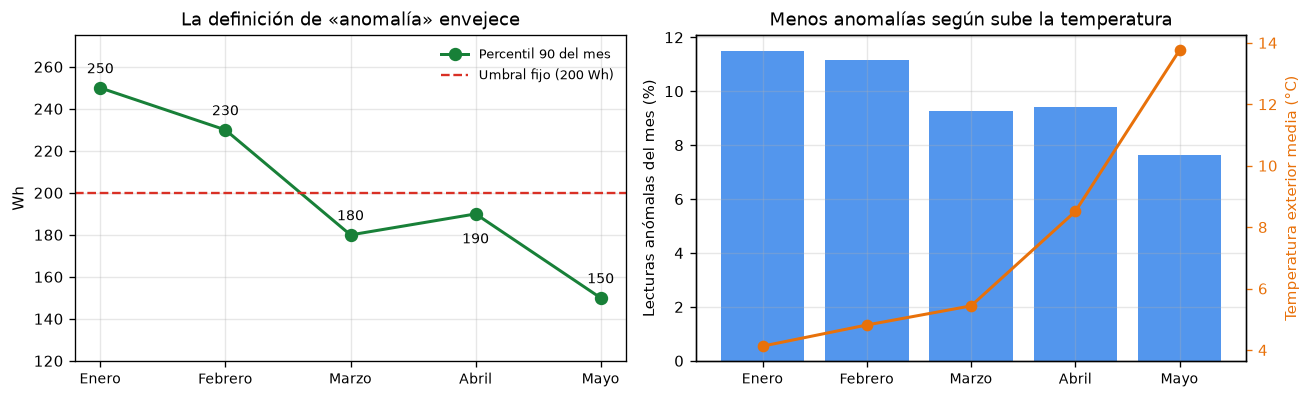

In [17]:
deriva = df.groupby(df.date.dt.to_period("M")).agg(
    lecturas=("Appliances", "size"), media=("Appliances", "mean"), mediana=("Appliances", "median"),
    p90=("Appliances", lambda s: np.percentile(s, 90)),
    tasa_anomalia_pct=("Appliances", lambda s: (s > UMBRAL).mean() * 100),
    T_out_media=("T_out", "mean"))
deriva.index = ["Enero", "Febrero", "Marzo", "Abril", "Mayo"]
print(deriva.round(2).to_string())
print(f"\nEl umbral de anomalía se fijó en {UMBRAL:.0f} Wh sobre datos de entrenamiento (sobre todo invierno).")
print(f"En mayo, el percentil 90 real del mes es {deriva.loc['Mayo','p90']:.0f} Wh.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
mm = deriva.index
ax[0].plot(mm, deriva.p90, "o-", color=COL["rf"], lw=1.8, ms=7, label="Percentil 90 del mes")
ax[0].axhline(UMBRAL, ls="--", lw=1.4, color=COL["alerta"], label=f"Umbral fijo ({UMBRAL:.0f} Wh)")
for i, v in enumerate(deriva.p90):
    dy = -14 if abs(v - UMBRAL) < 15 else 7          # evita que la etiqueta pise el umbral
    ax[0].text(i, v + dy, f"{v:.0f}", ha="center", fontsize=8.5)
ax[0].set(ylabel="Wh", ylim=(120, 275), title="La definición de «anomalía» envejece")
ax[0].legend(frameon=False, fontsize=8)
ax[0].tick_params(axis="x", labelsize=8.5)

ax2 = ax[1].twinx()
ax[1].bar(mm, deriva.tasa_anomalia_pct, color=COL["knn"], alpha=.75)
ax2.plot(mm, deriva.T_out_media, "o-", color=COL["arbol"], lw=1.8, ms=6)
ax[1].set(ylabel="Lecturas anómalas del mes (%)", title="Menos anomalías según sube la temperatura")
ax2.set_ylabel("Temperatura exterior media (°C)", color=COL["arbol"])
ax2.tick_params(axis="y", colors=COL["arbol"]); ax2.grid(False)
ax[1].tick_params(axis="x", labelsize=8.5)
plt.tight_layout(); plt.savefig(FIG / "P3_deriva.png"); plt.show()

**El umbral se descalibra solo en cuatro meses.** El percentil 90 del consumo cae de **250 Wh en
enero a 150 Wh en mayo**, mientras la temperatura exterior sube de 4,1 °C a 13,8 °C. El umbral de
200 Wh, fijado sobre datos de invierno, en mayo está **por encima** del percentil 90 real del mes:
lo que el sistema sigue llamando "normal" ya es, para ese mes, consumo alto.

Esto agrava el problema del punto 2. No solo el modelo envejece: **la definición misma de anomalía
envejece**. Un sistema desplegado en enero y no recalibrado estaría, en mayo, midiendo con una regla
equivocada — y el dataset ni siquiera llega al verano, donde la brecha sería mayor.

## 3.2 ¿Qué pasa si el modelo falla, y a quién le cuesta?

In [18]:
cm_rf = confusion_matrix(c_te, rf_c.predict(X_te))
cm_bal = confusion_matrix(c_te, svm_b.predict(Xs_te))
riesgos = pd.DataFrame([
    dict(Error="Falso negativo — no avisa de un pico real",
         RF=f"{cm_rf[1,0]} de {c_te.sum()} ({cm_rf[1,0]/c_te.sum()*100:.0f} %)",
         SVM_balanceado=f"{cm_bal[1,0]} de {c_te.sum()} ({cm_bal[1,0]/c_te.sum()*100:.0f} %)",
         Quien_lo_paga="La familia, en la factura del mes siguiente. Recuperable: la persona ve el recibo.",
         Gravedad="Media"),
    dict(Error="Falso positivo — avisa sin que pase nada",
         RF=f"{cm_rf[0,1]} de {(c_te==0).sum()} ({cm_rf[0,1]/(c_te==0).sum()*100:.1f} %)",
         SVM_balanceado=f"{cm_bal[0,1]} de {(c_te==0).sum()} ({cm_bal[0,1]/(c_te==0).sum()*100:.1f} %)",
         Quien_lo_paga="La confianza en el sistema. NO recuperable: si molesta, se desinstala.",
         Gravedad="Alta"),
    dict(Error="Ahorro simulado que no existe",
         RF="sesgo −40,6 Wh en el cuartil alto", SVM_balanceado="—",
         Quien_lo_paga="Quien tome una decisión económica (o de compra de equipo) confiando en la cifra.",
         Gravedad="Alta"),
]).set_index("Error")
print(riesgos.to_string())

                                                                          RF        SVM_balanceado                                                                       Quien_lo_paga Gravedad
Error                                                                                                                                                                                          
Falso negativo — no avisa de un pico real                  181 de 379 (48 %)     128 de 379 (34 %)  La familia, en la factura del mes siguiente. Recuperable: la persona ve el recibo.    Media
Falso positivo — avisa sin que pase nada                  40 de 3568 (1.1 %)  433 de 3568 (12.1 %)              La confianza en el sistema. NO recuperable: si molesta, se desinstala.     Alta
Ahorro simulado que no existe              sesgo −40,6 Wh en el cuartil alto                     —    Quien tome una decisión económica (o de compra de equipo) confiando en la cifra.     Alta


### Los cuatro riesgos, y qué se propone para cada uno

**1. Sesgo de representatividad — el riesgo mayor y el mejor documentado.**
Todo lo que este proyecto sabe viene de **una** vivienda de bajo consumo en Bélgica durante 137 días
de invierno y primavera. Los números de las secciones anteriores muestran que el modelo ni siquiera
generaliza al *quinto mes de la misma casa*. Pretender que generaliza a un hogar colombiano —otro
clima, otra tarifa, otros aparatos, otra rutina— no tiene respaldo.
*Mitigación:* incorporar UCI Household (#235, 47 meses, otro país) como fuente secundaria para
**medir** la caída al cambiar de vivienda en lugar de suponerla, y presentar toda cifra de ahorro
como *simulada sobre una vivienda de referencia*, nunca como una promesa.

**2. Exclusión por asimetría de datos.** Los sensores interiores concentran el **60,7 %** de la
importancia del modelo, y la lectura inmediata sería: un hogar con menos instrumentación recibe
recomendaciones mucho peores — y es, con probabilidad, el hogar con menos recursos. Un sistema de
ahorro energético que sirve mejor a quien menos lo necesita invierte su propósito.

Antes de escribir esa conclusión conviene medirla, porque la advertencia sobre
`feature_importances_` con variables correlacionadas se aplica también aquí: **la importancia
agregada de un bloque no es el coste de perderlo.** La siguiente celda reentrena el sistema completo
sin los 18 sensores interiores y sin el clima salvo `T_out` — la instrumentación de un hogar
corriente con un medidor y una API pública del tiempo.

In [19]:
DEGRADADO = TEMPORALES + ["lights", "T_out"] + RETARDOS   # 13 variables
COMPLETO  = FEATURES + RETARDOS                            # 36 variables

def episodios_(b, gap=3):
    idx = np.where(b == 1)[0]
    if len(idx) == 0: return []
    return np.split(idx, np.where(np.diff(idx) > gap)[0] + 1)

cb_ = (dl.iloc[cl:][TARGET] > UMBRAL).astype(int).values
ca_ = (dl.iloc[:cl][TARGET] > UMBRAL).astype(int)
fechas_ = dl.iloc[cl:]["date"].values
dias_ = (pd.Timestamp(fechas_[-1]) - pd.Timestamp(fechas_[0])).total_seconds() / 86400
ep_r = episodios_(cb_); ix_r = set(np.concatenate(ep_r))

filas = []
for nombre, cols in [("Hogar instrumentado", COMPLETO), ("Hogar con pocos sensores", DEGRADADO)]:
    Xa_, Xb_ = dl.iloc[:cl][cols], dl.iloc[cl:][cols]
    clf_ = RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xa_, ca_)
    pr_ = (clf_.predict_proba(Xb_)[:, 1] >= 0.40).astype(int)
    ep_a = episodios_(pr_)
    det = sum(1 for e in ep_r if any(len(set(e) & set(a)) > 0 for a in ep_a))
    reg_ = LinearRegression().fit(Xa_, dl.iloc[:cl][TARGET])
    filas.append({"Configuración": nombre, "n_vars": len(cols),
                  "Eventos detectados (%)": det / len(ep_r) * 100,
                  "Alertas/día": len(ep_a) / dias_,
                  "R² del simulador": r2_score(dl.iloc[cl:][TARGET], reg_.predict(Xb_))})
tabla_deg = pd.DataFrame(filas).set_index("Configuración")
print("¿CUÁNTO SE PIERDE SIN LOS SENSORES INTERIORES? (temporal, umbral 0,40)")
print(tabla_deg.round(3).to_string())
print(f"\nCaída en cobertura de eventos: "
      f"{tabla_deg.iloc[0]['Eventos detectados (%)'] - tabla_deg.iloc[1]['Eventos detectados (%)']:.1f} "
      f"puntos porcentuales.")

# Además: ¿cuántas variables hacen falta de verdad para el simulador?
SEIS = ["hora", "lights", "T2", "RH_2", "T_out", "lag1"]
m6 = LinearRegression().fit(dl.iloc[:cl][SEIS], dl.iloc[:cl][TARGET])
p6 = m6.predict(dl.iloc[cl:][SEIS])
print(f"\nSimulador con solo 6 variables ({', '.join(SEIS)}):")
print(f"  R² {r2_score(dl.iloc[cl:][TARGET], p6):+.4f} · MAE {mean_absolute_error(dl.iloc[cl:][TARGET], p6):.2f} Wh "
      f"— el de 36 variables da R² +0,557 · MAE 28,17 Wh")
print("  coeficientes:", {k: round(v, 4) for k, v in zip(SEIS, m6.coef_)},
      "· intercepto", round(m6.intercept_, 4))

¿CUÁNTO SE PIERDE SIN LOS SENSORES INTERIORES? (temporal, umbral 0,40)
                          n_vars  Eventos detectados (%)  Alertas/día  R² del simulador
Configuración                                                                          
Hogar instrumentado           36                  86.905        3.030             0.557
Hogar con pocos sensores      13                  77.381        3.468             0.560

Caída en cobertura de eventos: 9.5 puntos porcentuales.

Simulador con solo 6 variables (hora, lights, T2, RH_2, T_out, lag1):
  R² +0.5358 · MAE 28.85 Wh — el de 36 variables da R² +0,557 · MAE 28,17 Wh
  coeficientes: {'hora': np.float64(0.3772), 'lights': np.float64(0.7726), 'T2': np.float64(-0.1388), 'RH_2': np.float64(-0.8008), 'T_out': np.float64(0.7555), 'lag1': np.float64(0.7343)} · intercepto 49.1819


**La conclusión honesta es más matizada que la alarma inicial.** Al quitar los 18 sensores
interiores y casi todo el clima, la cobertura de eventos baja de **86,9 % a 77,4 %** —9,5 puntos—
y los avisos diarios suben de 3,0 a 3,5. El simulador, en cambio, **no se degrada en absoluto**
(R² +0,560 frente a +0,557).

La razón es la misma que hace tan potentes a los retardos: el consumo reciente de la propia vivienda
ya contiene casi toda la información que las temperaturas interiores aportaban. Eran, en buena
medida, redundantes. Ese 60,7 % de importancia mide cuánto *usa* el bosque esas variables cuando las
tiene, no cuánto *necesita* de ellas.

Para Shiro esto cambia dos cosas. **La brecha de equidad existe pero es mucho menor de lo que
parecía**, y el **modo degradado deja de ser un gesto para convertirse en una configuración
defendible**: un hogar con un solo medidor y el pronóstico del tiempo obtiene el 89 % de la
cobertura del hogar instrumentado y exactamente el mismo simulador. Sigue siendo obligatorio
declararlo en pantalla — 9,5 puntos no son cero, y los avisos falsos suben.

*Mitigación:* mantener el **modo degradado explícito**, con su menor cobertura declarada en la
interfaz, en vez de aparentar la misma confianza.

**3. Explicabilidad — y por qué el modelo peor sigue en el proyecto.**
El árbol de decisión individual (R² 0,325) es sustancialmente peor que Random Forest (0,567), pero
se puede leer: su primera regla es `hora ≤ 7,5` y separa la casa dormida (54,9 Wh) de la casa activa
(119,6 Wh). Random Forest son **200 árboles promediados**: nadie puede mirarlos y decir por qué
sugirió lo que sugirió. Y hay una trampa adicional ya verificada: `T1`–`T9` son habitaciones de la
misma casa y están correlacionadas, así que su ranking individual de importancia **no es
interpretable** — solo el peso agregado por bloque lo es. Decir "el sistema recomendó esto por el
sensor 8" sería inventarse una explicación.
*Mitigación:* mantener el árbol en producción **como capa de explicación**. Random Forest decide, el
árbol responde "por qué".

In [20]:
print("La regla que Shiro puede enseñarle a una persona (primeros dos niveles del árbol):\n")
print(export_text(arbol, feature_names=list(FEATURES), max_depth=2, decimals=1))

La regla que Shiro puede enseñarle a una persona (primeros dos niveles del árbol):

|--- hora <= 7.5
|   |--- hora <= 6.5
|   |   |--- T9 <= 19.5
|   |   |   |--- truncated branch of depth 13
|   |   |--- T9 >  19.5
|   |   |   |--- truncated branch of depth 13
|   |--- hora >  6.5
|   |   |--- RH_6 <= 41.0
|   |   |   |--- truncated branch of depth 4
|   |   |--- RH_6 >  41.0
|   |   |   |--- truncated branch of depth 12
|--- hora >  7.5
|   |--- hora <= 20.5
|   |   |--- lights <= 5.0
|   |   |   |--- truncated branch of depth 13
|   |   |--- lights >  5.0
|   |   |   |--- truncated branch of depth 13
|   |--- hora >  20.5
|   |   |--- hora <= 21.5
|   |   |   |--- truncated branch of depth 13
|   |   |--- hora >  21.5
|   |   |   |--- truncated branch of depth 13



**4. Responsabilidad y confianza.** *¿Quién responde si el modelo falla?* En Shiro Twin la respuesta
está resuelta por diseño y no por conveniencia: **el agente propone y la persona aprueba**. El
principio viene del asistente Shiro, donde ya rige para acciones sensibles, y aquí se traslada al
plano energético. Ninguna acción del sistema modifica el estado de la casa sin confirmación humana.
Es lo que convierte un error del modelo en una sugerencia rechazable en lugar de un daño.

Y hay una razón medida para no maximizar el recall a toda costa: **una anomalía perdida es
recuperable** —la persona ve la factura y ajusta—, pero **demasiadas falsas alarmas destruyen la
confianza y el sistema termina desinstalado**. El SVM balanceado detecta el 66 % de las anomalías
frente al 52 % de Random Forest, pero produce 433 falsas alarmas contra 40. La respuesta correcta no
es un modelo, sino un **umbral que la persona controle** — que es exactamente lo que construye el
punto 4.

---
# Punto 4 — Simulación de decisión automatizada

**Decisión de Shiro que depende de esto:** el lazo del módulo `iot-bridge` — cómo una predicción se
convierte en algo que una persona ve, aprueba o rechaza.

## 4.1 La lógica del sistema

```
SI  probabilidad_de_anomalía ≥ umbral_del_usuario
    Y el consumo estimado supera el percentil configurado
ENTONCES  notificar, explicar con la regla del árbol, y PROPONER una acción diferible
          → la acción NO se ejecuta hasta que la persona la apruebe

SI  probabilidad_de_anomalía < umbral_del_usuario
ENTONCES  registrar en el histórico sin molestar

SI  el modelo lleva más de 30 días sin reentrenar
    O el mes actual no estaba representado en el entrenamiento
ENTONCES  mostrar la predicción con aviso de baja confianza y no proponer acción automática
```

La tercera regla no es un adorno: sale directamente de la sección 3.1, donde se vio que el umbral se
descalibra solo en cuatro meses.

## 4.2 ¿Dónde poner el umbral? — la pregunta que decide la experiencia de uso

El umbral por defecto de cualquier clasificador es 0,50, pero esa cifra no tiene nada de especial. Lo
que una persona experimenta no son lecturas sueltas cada diez minutos, sino **episodios**: si el
consumo está alto durante media hora, eso es *un* evento, no tres notificaciones.

La simulación se hace sobre la **partición temporal con retardos** —el escenario real de despliegue,
donde el sistema ve un flujo continuo— agrupando en un mismo episodio las alertas separadas por menos
de 30 minutos.

In [21]:
COLS_DEP = FEATURES + RETARDOS
Xa, Xb = dl.iloc[:cl][COLS_DEP], dl.iloc[cl:][COLS_DEP]
ca = (dl.iloc[:cl][TARGET] > UMBRAL).astype(int)
cb = (dl.iloc[cl:][TARGET] > UMBRAL).astype(int).values
fechas = dl.iloc[cl:]["date"].values
dias = (pd.Timestamp(fechas[-1]) - pd.Timestamp(fechas[0])).total_seconds() / 86400

modelo_dep = RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xa, ca)
proba = modelo_dep.predict_proba(Xb)[:, 1]

def episodios(binaria, gap=3):
    # Agrupa en un mismo episodio las lecturas positivas separadas por menos de `gap` lecturas (30 min)
    idx = np.where(binaria == 1)[0]
    if len(idx) == 0: return []
    return np.split(idx, np.where(np.diff(idx) > gap)[0] + 1)

ep_reales = episodios(cb)
print(f"Simulación de despliegue: {dias:.1f} días continuos "
      f"({pd.Timestamp(fechas[0]).date()} → {pd.Timestamp(fechas[-1]).date()})")
print(f"Episodios reales de consumo alto: {len(ep_reales)}  ({len(ep_reales)/dias:.1f} por día)\n")

reales_ix = set(np.concatenate(ep_reales))

def barrido(proba_, etiqueta):
    filas = []
    for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (proba_ >= t).astype(int)
        ep_a = episodios(p)
        detectados = sum(1 for e in ep_reales if any(len(set(e) & set(a)) > 0 for a in ep_a))
        utiles = sum(1 for a in ep_a if reales_ix & set(a))
        filas.append({"Umbral": t, "Alertas/día": len(ep_a) / dias,
                      "Eventos detectados (%)": detectados / len(ep_reales) * 100,
                      "Alertas falsas (%)": (len(ep_a) - utiles) / max(len(ep_a), 1) * 100,
                      "Recall (lectura)": recall_score(cb, p),
                      "F1 (lectura)": f1_score(cb, p, zero_division=0)})
    print(f"\n--- {etiqueta} ---")
    print(pd.DataFrame(filas).set_index("Umbral").round(2).to_string())
    return pd.DataFrame(filas).set_index("Umbral")

tabla_umbral = barrido(proba, "Random Forest + retardos")

# Contraste: el clasificador con MEJOR F1 por lectura bajo partición temporal
sc_dep = StandardScaler().fit(Xa)
log_dep = LogisticRegression(max_iter=2000).fit(sc_dep.transform(Xa), ca)
tabla_log = barrido(log_dep.predict_proba(sc_dep.transform(Xb))[:, 1],
                    "Regresión Logística + retardos (mejor F1 por lectura: 0,657)")

Simulación de despliegue: 27.4 días continuos (2016-04-30 → 2016-05-27)
Episodios reales de consumo alto: 84  (3.1 por día)




--- Random Forest + retardos ---
        Alertas/día  Eventos detectados (%)  Alertas falsas (%)  Recall (lectura)  F1 (lectura)
Umbral                                                                                         
0.2            2.70                   97.62               52.70              0.96          0.28
0.3            2.92                   91.67               43.75              0.91          0.35
0.4            3.03                   86.90               37.35              0.85          0.47
0.5            3.83                   75.00               38.10              0.57          0.57
0.6            2.01                   45.24               20.00              0.26          0.40
0.7            0.40                   11.90                0.00              0.08          0.15



--- Regresión Logística + retardos (mejor F1 por lectura: 0,657) ---
        Alertas/día  Eventos detectados (%)  Alertas falsas (%)  Recall (lectura)  F1 (lectura)
Umbral                                                                                         
0.2            2.70                   70.24               32.43              0.71          0.65
0.3            2.85                   64.29               32.05              0.65          0.67
0.4            2.70                   63.10               25.68              0.61          0.67
0.5            2.74                   61.90               25.33              0.57          0.66
0.6            2.56                   59.52               21.43              0.49          0.60
0.7            2.34                   53.57               21.88              0.42          0.56


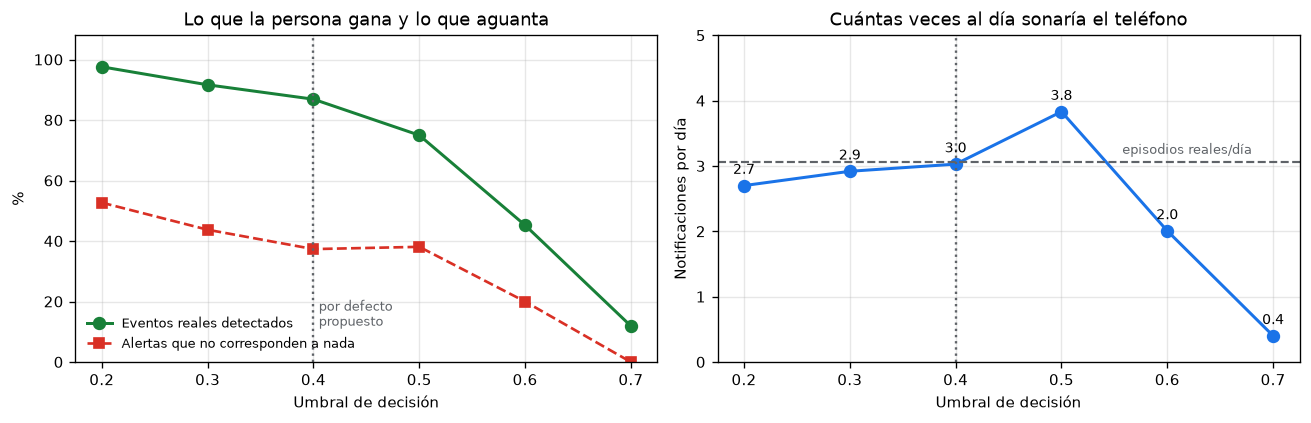

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
u = tabla_umbral.index.values

ax[0].plot(u, tabla_umbral["Eventos detectados (%)"], "o-", color=COL["rf"], lw=1.8, ms=7,
           label="Eventos reales detectados")
ax[0].plot(u, tabla_umbral["Alertas falsas (%)"], "s--", color=COL["alerta"], lw=1.6, ms=6,
           label="Alertas que no corresponden a nada")
ax[0].axvline(.40, color="#5f6368", ls=":", lw=1.4)
ax[0].text(.405, 12, "por defecto\npropuesto", fontsize=7.5, color="#5f6368")
ax[0].set(xlabel="Umbral de decisión", ylabel="%", ylim=(0, 108),
          title="Lo que la persona gana y lo que aguanta")
ax[0].legend(frameon=False, fontsize=7.5, loc="lower left")

ax[1].plot(u, tabla_umbral["Alertas/día"], "o-", color=COL["knn"], lw=1.8, ms=7)
ax[1].axhline(len(ep_reales) / dias, ls="--", lw=1.3, color="#5f6368")
ax[1].text(.68, len(ep_reales) / dias + .12, "episodios reales/día", fontsize=7.5,
           ha="right", color="#5f6368")
ax[1].axvline(.40, color="#5f6368", ls=":", lw=1.4)
for x, v in zip(u, tabla_umbral["Alertas/día"]):
    ax[1].text(x, v + .18, f"{v:.1f}", ha="center", fontsize=8.5)
ax[1].set(xlabel="Umbral de decisión", ylabel="Notificaciones por día", ylim=(0, 5),
          title="Cuántas veces al día sonaría el teléfono")
plt.tight_layout(); plt.savefig(FIG / "P4_umbral.png"); plt.show()

### El valor por defecto propuesto: 0,40

Con umbral **0,40** el sistema envía **3,0 notificaciones al día** —prácticamente la misma frecuencia
con que ocurren los episodios reales (3,1/día)— y avisa del **86,9 % de los eventos reales de consumo
alto**, con un 37 % de alertas que no corresponden a nada.

El valor por defecto de 0,50 detectaría solo el **75 %** de los eventos; el de 0,70 caería al **12 %**
y volvería el sistema inútil. Bajarlo a 0,20 sube la cobertura al 98 % pero **más de la mitad de los
avisos serían falsos** — y la sección 3.2 ya explicó por qué ese es el peor de los desenlaces: las
falsas alarmas gastan un recurso que no se recupera.

*(Las alertas por día no crecen de forma monótona al bajar el umbral: con umbrales bajos, las
lecturas positivas consecutivas se funden en episodios más largos y menos numerosos. Por eso 0,20
produce menos notificaciones que 0,50 aun marcando muchas más lecturas.)*

### Por qué el modelo elegido no es el de mejor F1

El segundo barrido de la celda anterior usa **regresión logística con retardos**, que bajo partición
temporal tiene un F1 por lectura de **0,657 frente al 0,473 de Random Forest** — es, con la métrica
del curso, claramente el mejor clasificador. Y sin embargo es peor producto:

| Con ~2,7–3,0 alertas/día | Eventos reales detectados | Alertas falsas | F1 por lectura |
|---|---|---|---|
| Random Forest (umbral 0,40) | **86,9 %** | 37,3 % | 0,473 |
| Regresión Logística (umbral 0,20) | 70,2 % | 32,4 % | **0,651** |

Con el mismo presupuesto de notificaciones, Random Forest avisa de **17 puntos porcentuales más de
eventos reales**. La razón es que la logística reparte su confianza de forma más plana dentro de cada
episodio: acierta más lecturas sueltas, pero se le escapan episodios enteros que nunca cruzan el
umbral en ninguna de sus lecturas.

**La métrica que el curso optimiza elige el modelo equivocado para este producto.** Lo que una
persona experimenta no son lecturas cada diez minutos sino eventos, y el F1 por lectura no mide eso.
Es la misma lección del punto 1 —el criterio de validación importa más que el algoritmo— aplicada
ahora a la métrica.

**Por eso el umbral es un control del usuario y no una constante del código.** Alguien que paga una
tarifa muy alta querrá 0,20 y tolerará el ruido; alguien que solo quiere una alerta ocasional pondrá
0,60. La misma tabla parametriza las dos configuraciones.

> **Nota de honestidad sobre estas cifras.** Están calculadas sobre 27 días de una vivienda, con el
> clasificador que incluye retardos y bajo validación temporal — el escenario más exigente de los que
> se probaron. Aun así proceden de un único hogar: son un orden de magnitud para dimensionar la
> interfaz, no una garantía de servicio.

## 4.3 Explicación del caso de uso

**¿Por qué automatizar esto?** Porque la información llega tarde. Hoy una familia se entera de su
consumo cuando llega la factura, entre veinte y cincuenta días después de haberlo gastado, y agregado
en una sola cifra que no dice qué lo causó. La detección en el momento convierte un número mensual
sin accionabilidad en un aviso con contexto: *"esto está pasando ahora, esta es la franja, esta es la
regla por la que te aviso"*.

**¿Qué ventaja aporta?** Tres, en orden de solidez:

1. **Inmediatez** — el aviso llega mientras el consumo ocurre, cuando todavía se puede actuar.
2. **Atribución** — la capa de explicación (el árbol) nombra la regla: hora, franja, ocupación
   estimada. Un número sin causa no cambia una conducta.
3. **Diferimiento** — algunas cargas se pueden mover a otra franja sin perder comodidad. Es la
   ventaja mayor y la que el proyecto **todavía no puede cuantificar**: requiere el agente de
   refuerzo del tercer corte. Lo que este parcial aporta es que ese agente ya tiene sobre qué
   entrenarse: un simulador validado temporalmente (§2.5), que al empezar el corte no existía.

**¿Qué pasa si el modelo falla?** Está medido, no supuesto. Con umbral 0,40, **13 de cada 100 eventos
reales pasan desapercibidos** y **37 de cada 100 avisos son falsos**. La consecuencia de lo primero
es una factura algo mayor y recuperable; la de lo segundo es la erosión de la confianza, que no se
recupera. Por eso el diseño incluye tres salvaguardas, cada una respondiendo a un hallazgo concreto
de este cuaderno:

| Salvaguarda | Hallazgo que la motiva |
|---|---|
| **Ninguna acción se ejecuta sin aprobación** — el sistema solo propone | El modelo subestima los picos en −40,6 Wh: automatizar ciegamente produciría un ahorro reportado que no existe (§2.2) |
| **Umbral ajustable por la persona, no constante del código** | El equilibrio entre cobertura y ruido no tiene un óptimo universal (§4.2) |
| **Aviso de baja confianza y recalibración periódica** | El percentil 90 cae de 250 a 150 Wh en cuatro meses: el umbral se descalibra solo (§3.1) |

**¿Se debe permitir override manual?** Sí, y no como concesión sino como parte del diseño. Una
persona tiene contexto que el modelo no tiene y que **ninguna de las 29 variables puede capturar**:
que hay visitas, que se está lavando ropa a propósito, que alguien está enfermo y la casa debe estar
más caliente. El Caso A del punto 2 es exactamente eso — un pico de 800 Wh que ninguna variable
anunciaba. El override no corrige un defecto del sistema: **es la única vía por la que entra la
información que al sistema le falta.**

---

## Cierre — qué cambia en el diseño de Shiro por causa de este parcial

1. **La función de transición del gemelo digital ya tiene modelo, y no es el que ganó.** Regresión
   lineal sobre variables de retardo: **R² 0,557 y MAE 28,17 Wh sobre un mes nunca visto** (§2.5),
   equivalente al mejor resultado del proyecto pero en la partición difícil. Random Forest queda
   descartado para simular: no extrapola, y arrastra un sesgo de +64 Wh sobre todo el mes de prueba.
2. **El criterio de validación pesa más que el algoritmo.** Bajo partición aleatoria el orden era
   RF > KNN > Árbol > Lineal; bajo partición temporal se invierte por completo (§1). Toda decisión de
   arquitectura de Shiro se toma, de aquí en adelante, sobre validación temporal.
3. **La capa de detección tiene respaldo empírico y se adelanta en el orden del proyecto.** El
   clasificador con retardos pasa de F1 0,167 a **0,580** bajo validación temporal (§2.4), y a nivel
   de episodio detecta el 86,9 % de los eventos reales con 3 avisos diarios (§4.2). **Shiro Guardian,
   que la propuesta clasificaba como objetivo opcional, es hoy la parte más sólida del trabajo.**
4. **La incertidumbre del entorno debe ser función de la hora**, no una constante: el MAE va de
   7,3 Wh de madrugada a 42,1 Wh en la mañana (§2.2). Un simulador con incertidumbre uniforme
   invitaría al agente a explotar justo las horas menos fiables.
5. **El umbral de anomalía debe recalibrarse periódicamente**, porque la definición de anomalía se
   mueve con la estación: el percentil 90 cae de 250 a 150 Wh entre enero y mayo (§3.1). No solo
   envejece el modelo; envejece el criterio.
6. **La métrica de evaluación del clasificador debe medirse por episodio, no por lectura** (§4.2).
   Con F1 por lectura se elegiría un modelo que detecta 17 puntos porcentuales menos de los eventos
   que una persona querría conocer.
7. **`lights` merece más peso del que el modelo le da solo.** Es el proxy de ocupación que el dataset
   no trae etiquetado y pesa apenas 2,9 %; el Caso B falló teniéndolo delante (§2.3).
8. **El modo degradado es una configuración defendible, no un gesto.** Sin los 18 sensores
   interiores la cobertura baja 9,5 puntos (86,9 % → 77,4 %) y el simulador no baja nada (§3.3).
   La brecha de equidad es real pero mucho menor que el 60,7 % de importancia agregada que la
   sugería: **importancia no es coste de pérdida**, ni siquiera a nivel de bloque.

**Lo que sigue (2.º corte).** El punto 1 del cronograma de la propuesta —construir el entorno de
simulación— pasa de bloqueado a viable, con la especificación ya decidida: regresión lineal con
retardos como función de transición, incertidumbre por franja horaria y validación temporal
obligatoria antes de que el agente entrene. A eso se suman el clustering de rutinas con al menos dos
técnicas comparadas y la formalización escrita del MDP. Sigue pendiente incorporar UCI Household
(#235) para medir la caída al cambiar de vivienda, que es la única de las debilidades declaradas que
este parcial no ha podido cuantificar.